# Imports and Helpers

In [1]:
import itertools
import string
from tqdm.auto import trange
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict, Counter
import numpy as np
import pickle
import hdbscan
from sklearn.decomposition import PCA
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_samples, silhouette_score, davies_bouldin_score, calinski_harabasz_score
import plotly.express as px
from matplotlib import colors as mcolors
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances


In [40]:
def get_reaction_type(tps_type, original_type, tps_class, original_type_2_class):
    type_correction = {"pt": "isoprenyl diphosphate synthase", "sesq": "sesqui"}
    corrected_type = type_correction.get(tps_type, tps_type)

    if tps_type in {"tri", "tetra"}:
        if original_type == "sqs":
            return f"squalene synthase"
        elif original_type == "psy":
            return f"phytoene synthase"

    if len(original_type_2_class[tps_type]) == 1:
        return corrected_type
    elif len(original_type_2_class[tps_type]) > 1:
        return f"{corrected_type} (Class {tps_class})"
    return False


def _default_group_key(label: str) -> str:
    return label.split()[0] if label.strip() else ""


def build_label_color_mapping_reserved_hue(
    reaction_types,
    group_key_fn=None,
    *,
    base_s=0.85,
    base_v=0.85,
    # hard constraints
    min_group_sep=0.06,  # minimum hue distance between group base hues (0..1)
    safety=0.45,  # fraction of neighbor gap reserved for within-group tones
    max_intragroup_span=0.20,  # cap, in case gaps are huge
    seed=0,
):
    """
    Guarantees:
      - Each group has a distinct base hue.
      - Within-group hues lie inside a reserved interval around the base hue that
        does not overlap neighboring groups' reserved intervals (by construction).
    """
    if group_key_fn is None:
        group_key_fn = _default_group_key

    # group labels
    group_to_labels = {}
    for lab in reaction_types:
        g = group_key_fn(lab)
        group_to_labels.setdefault(g, []).append(lab)

    for g in group_to_labels:
        group_to_labels[g] = sorted(group_to_labels[g])
    groups = sorted(group_to_labels.keys())
    n_groups = len(groups)
    if n_groups == 0:
        return {}, {}

    # --- propose base hues via golden-ratio stepping ---
    phi = 0.618033988749895
    rng = np.random.default_rng(seed)
    h0 = float(rng.random())

    base_hues = []
    h = h0
    for _ in range(n_groups):
        base_hues.append(h % 1.0)
        h += phi

    # --- enforce minimum separation (simple rejection/adjustment) ---
    # For typical n_groups <= ~15 and min_group_sep ~0.06, this is fine.
    # If too many groups for the requested min_sep, we relax min_sep automatically.
    max_possible_sep = 1.0 / n_groups
    if min_group_sep > max_possible_sep:
        min_group_sep = 0.9 * max_possible_sep  # best-effort

    def circular_dist(a, b):
        d = abs(a - b) % 1.0
        return min(d, 1.0 - d)

    # small iterative "jitter" to reduce near-collisions
    base_hues = np.array(base_hues, dtype=float)
    for _ in range(2000):
        ok = True
        for i in range(n_groups):
            for j in range(i + 1, n_groups):
                if circular_dist(base_hues[i], base_hues[j]) < min_group_sep:
                    ok = False
                    # push j slightly
                    base_hues[j] = (base_hues[j] + min_group_sep) % 1.0
        if ok:
            break

    # Map group -> base hue (keep group order stable but base hues are as constructed)
    group_to_base_h = {g: float(h) for g, h in zip(groups, base_hues.tolist())}

    # --- reserve a non-overlapping hue interval per group ---
    # Work on sorted-by-hue groups to compute neighbor gaps
    sorted_pairs = sorted(group_to_base_h.items(), key=lambda kv: kv[1])
    sorted_groups = [g for g, _ in sorted_pairs]
    sorted_hues = np.array([h for _, h in sorted_pairs], dtype=float)

    # circular gaps between consecutive base hues
    gaps = np.diff(np.r_[sorted_hues, sorted_hues[0] + 1.0])  # size n_groups
    # each group can use at most safety * min(left_gap, right_gap)
    # left_gap for i is gaps[i-1], right_gap is gaps[i]
    left_gaps = np.r_[gaps[-1], gaps[:-1]]
    right_gaps = gaps
    min_neighbor_gap = np.minimum(left_gaps, right_gaps)

    group_to_span = {}
    for g, h, mg in zip(sorted_groups, sorted_hues, min_neighbor_gap):
        span = min(max_intragroup_span, safety * mg)
        # ensure non-zero span if a group has multiple labels
        group_to_span[g] = float(max(span, 0.0))

    # --- assign label colors ---
    label_to_color = {}
    for g in groups:
        labels = group_to_labels[g]
        k = len(labels)
        base_h = group_to_base_h[g]
        span = group_to_span[g]

        if k == 1 or span == 0.0:
            hues = [base_h]
        else:
            # evenly spaced within [base_h - span/2, base_h + span/2]
            half = span / 2.0
            offsets = np.linspace(-half, half, k)
            hues = [(base_h + off) % 1.0 for off in offsets]

        for lab, hh in zip(labels, hues):
            rgb = mcolors.hsv_to_rgb((float(hh), float(base_s), float(base_v)))
            label_to_color[lab] = tuple(rgb)

    return label_to_color, group_to_labels


def plot_multilabel_pca_scatter_all_label_legend(
    X_pca,
    labels_list,
    reaction_types,
    *,
    group_key_fn=None,
    base_alpha=0.65,
    normalize_alpha_by_cardinality=True,
    jitter=0.002,
    marker_size=18,
    legend_cols=1,
    legend_fontsize=14,
    legend_outside=True,
    title_fontsize=20,
    seed=1,
    safety=0.6,
    legend_title="Label",
    title="PCA Scatter Plot",
    medoids=None,
    label_to_color=None,
    markings:list[tuple[int, str]]=[],
):
    X_pca = np.asarray(X_pca)
    assert X_pca.ndim == 2 and X_pca.shape[1] == 2
    assert len(labels_list) == X_pca.shape[0]

    if not isinstance(labels_list[0], set):
        labels_list = [{labs} for labs in labels_list]

    if label_to_color is None:
        label_to_color, _ = build_label_color_mapping_reserved_hue(
            reaction_types=reaction_types,
            group_key_fn=group_key_fn,
            seed=seed,
            safety=safety,
        )

    rng = np.random.default_rng(seed)

    xs, ys, rgba, m_sizes = [], [], [], []
    for i, labs in enumerate(labels_list):
        if not labs:
            continue
        labs = list(set(labs))
        card = len(labs)
        a = (
            (base_alpha / card)
            if (normalize_alpha_by_cardinality and card > 0)
            else base_alpha
        )

        for lab in labs:
            x, y = float(X_pca[i, 0]), float(X_pca[i, 1])
            if jitter > 0:
                x += rng.normal(0.0, jitter)
                y += rng.normal(0.0, jitter)

            rgb = label_to_color[lab]
            xs.append(x)
            ys.append(y)
            rgba.append((*rgb, float(a)))
            m_sizes.append(marker_size)
    if medoids is not None:
        for lab, medoid_idx in zip(reaction_types, medoids):
            x, y = float(X_pca[medoid_idx, 0]), float(X_pca[medoid_idx, 1])
            rgb = label_to_color[lab]
            xs.append(x)
            ys.append(y)
            rgba.append((*rgb, 1.0))  # full opacity for medoids
            m_sizes.append(marker_size * 20)  # larger size for medoids
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.scatter(xs, ys, s=m_sizes, c=np.asarray(rgba), linewidths=0)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_title(title, fontsize=title_fontsize)
    ax.grid(True, alpha=0.2)

    # Full label legend
    handles, leg_labels = [], []
    for lab in sorted(reaction_types):
        rgb = label_to_color.get(lab, (0.2, 0.2, 0.2))
        handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=rgb,
                markeredgecolor="none",
                markersize=7,
            )
        )
        leg_labels.append(lab)

    if legend_outside:
        ax.legend(
            handles,
            leg_labels,
            title=legend_title,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0.0,
            frameon=True,
            ncol=legend_cols,
            fontsize=legend_fontsize,
            title_fontsize=legend_fontsize,
        )
        plt.tight_layout(rect=[0, 0, 0.80, 1])
    else:
        ax.legend(
            handles,
            leg_labels,
            title=legend_title,
            loc="best",
            frameon=True,
            ncol=legend_cols,
            fontsize=legend_fontsize,
            title_fontsize=legend_fontsize,
        )
        plt.tight_layout()

    for marking in markings:
        idx = marking[0]
        annotation = marking[1]
        ax.annotate(annotation, (X_pca[idx, 0], X_pca[idx, 1]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=6, fontweight='bold', color='black')
        ax.scatter(X_pca[idx, 0], X_pca[idx, 1], s=50, c="black", marker="X", edgecolors="white", linewidths=0, alpha=0.7)
    return fig, ax, label_to_color


def plot_optimal_num_medoid_selection(
    silhouette_avg_all, davies_bouldin_all, calinski_harabasz_all, max_range=15
) -> int:
    best_silhouette = np.argmax(silhouette_avg_all) + 2
    best_davies_bouldin = np.argmin(davies_bouldin_all) + 2
    best_calinski_harabasz = np.argmax(calinski_harabasz_all) + 2

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    ax1.plot(range(2, max_range), silhouette_avg_all, marker="o")
    ax1.axvline(x=best_silhouette, ymax=0.95, color="red", linestyle="--")

    ax1.set_title(
        "Average Silhouette Coefficients",
        fontsize=14,
    )
    ax1.set_xlabel("Number of Medoids", fontsize=10)
    ax1.set_ylabel("Average Silhouette Coefficient", fontsize=10)
    ax1.set_xticks(list(range(2, max_range)))
    ax1.legend(["Individual experiments", "Optimal medoid count"])

    ax2.plot(range(2, max_range), davies_bouldin_all, marker="o")
    ax2.axvline(x=best_davies_bouldin, ymax=0.95, color="red", linestyle="--")
    ax2.set_title(
        "Davies-Bouldin Indexes",
        fontsize=14,
    )
    ax2.set_xlabel("Number of Medoids", fontsize=10)
    ax2.set_ylabel("Davies-Bouldin Index", fontsize=10)
    ax2.set_xticks(list(range(2, max_range)))
    ax2.legend(["Individual experiments", "Optimal medoid count"])

    ax3.plot(range(2, max_range), calinski_harabasz_all, marker="o")
    ax3.axvline(x=best_calinski_harabasz, ymax=0.95, color="red", linestyle="--")
    ax3.set_title(
        "Calinski-Harabasz Indexes",
        fontsize=14,
    )
    ax3.set_xlabel("Number of Medoids", fontsize=10)
    ax3.set_ylabel("Calinski-Harabasz Index", fontsize=10)
    ax3.set_xticks(list(range(2, max_range)))
    ax3.legend(["Individual experiments", "Optimal medoid count"])

    ctr = Counter([best_silhouette, best_davies_bouldin, best_calinski_harabasz])
    if len(ctr.most_common()) > 1:
        return int(best_silhouette)  # default to silhouette if no clear majority
    return int(ctr.most_common()[0][0])


def plot_silhouette_analysis(domains_dist_matrice, cluster_labels, title="Silhouette Plot for Optimal Medoids"):
    color_discrete_sequence = (
        px.colors.qualitative.Dark24
        + px.colors.qualitative.Light24
        + px.colors.qualitative.Pastel1
        + px.colors.qualitative.Pastel2
        + px.colors.qualitative.Set3
    )
    
    sample_silhouette_values = silhouette_samples(
        domains_dist_matrice, cluster_labels, metric="precomputed"
    )

    _, ax = plt.subplots(figsize=(4, 3))
    y_lower = 10
    for i, label in enumerate(np.unique(cluster_labels)):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == label]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = color_discrete_sequence[i % len(cluster_labels)]
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax.text(-0.30, y_lower + 0.2 * size_cluster_i, label)

        y_lower = y_upper + 10

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("The silhouette coefficient values", fontsize=10)
    ax.set_ylabel("Cluster label", fontsize=10)
    ax.set_yticks([])
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])


def fill_noise_with_closest_label(labels_, domains_dist_matrice, n_neighbs=3):
    for i, val in enumerate(labels_):
        if labels_[i] == -1:
            label_counts = defaultdict(int)
            neighbours = np.argsort(domains_dist_matrice[i, :])
            n_found = 0
            for neighb_i in neighbours:
                if labels_[neighb_i] != -1:
                    label_counts[labels_[neighb_i]] += 1
                    n_found += 1
                if n_found >= n_neighbs:
                    break
            labels_[i] = max(label_counts.items(), key=lambda el: el[1])[0]


def get_pca_analysis(
    domains_dist_matrice,
    dom_reaction_types,
    all_reaction_types,
    title,
    legend_title,
    legend_cols=1,
    marker_size=18,
    markings:list[tuple[int, str]]=[],
    group_key_fn=lambda s: s.split()[0],
    safety=0.9,
    base_alpha=0.65
):
    sc = StandardScaler()
    scaled_dist_matrice = sc.fit_transform(domains_dist_matrice)
    pca = PCA(n_components=2)
    pca_coord_dom = pca.fit_transform(scaled_dist_matrice)
    explained_variance = pca.explained_variance_ratio_

    if not isinstance(dom_reaction_types[0], set):
        dom_reaction_types = [{rts} for rts in dom_reaction_types]

    fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
        pca_coord_dom,
        dom_reaction_types,
        all_reaction_types,
        group_key_fn=group_key_fn,  # or s.split("_")[0]
        jitter=0.002,
        legend_cols=legend_cols,
        legend_fontsize=12,
        title_fontsize=20,
        seed=1,
        safety=safety,
        legend_title=legend_title,
        title=f"{title}\n{sum(explained_variance)*100:.0f}% of variation captured",
        markings=markings,
        marker_size=marker_size,
        base_alpha=base_alpha
    )
    return pca_coord_dom, explained_variance


def get_umap_analysis(   
    domains_dist_matrice,
    dom_reaction_types,
    all_reaction_types,
    title,
    legend_title,
    legend_cols=1,
    marker_size=18,
    markings:list[tuple[int, str]]=[],
    group_key_fn=lambda s: s.split()[0],
    safety=0.9,
    base_alpha=0.65
):  
    umap = UMAP(metric="precomputed", random_state=1)
    umap_coord_dom = umap.fit_transform(domains_dist_matrice)

    if not isinstance(dom_reaction_types[0], set):
        dom_reaction_types = [{rts} for rts in dom_reaction_types]

    fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
        umap_coord_dom,
        dom_reaction_types,
        all_reaction_types,
        group_key_fn=group_key_fn,  # or s.split("_")[0]
        jitter=0.002,
        legend_cols=legend_cols,
        legend_fontsize=12,
        title_fontsize=20,
        seed=1,
        safety=safety,
        legend_title=legend_title,
        title=f"{title}",
        markings=markings,
        marker_size=marker_size,
        base_alpha=base_alpha
    )
    return umap_coord_dom


def get_tsne_analysis(
    domains_dist_matrice,
    dom_reaction_types,
    all_reaction_types,
    title,
    legend_title,
    legend_cols=1,
    marker_size=18,
    markings:list[tuple[int, str]]=[],
    group_key_fn=lambda s: s.split()[0],
    safety=0.9,
    base_alpha=0.65
): 
    tsne = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3, metric="precomputed", random_state=1)
    tsne_coord_dom = tsne.fit_transform(domains_dist_matrice)

    if not isinstance(dom_reaction_types[0], set):
        dom_reaction_types = [{rts} for rts in dom_reaction_types]

    fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
        tsne_coord_dom,
        dom_reaction_types,
        all_reaction_types,
        group_key_fn=group_key_fn,  # or s.split("_")[0]
        jitter=0.002,
        legend_cols=legend_cols,
        legend_fontsize=12,
        title_fontsize=20,
        seed=1,
        safety=safety,
        legend_title=legend_title,
        title=f"{title}",
        markings=markings,
        marker_size=marker_size,
        base_alpha=base_alpha
    )
    return tsne_coord_dom

def get_cluster_label_to_domain_subtype_mappings(cluster_labels, domain_labels, level=1):
    cluster_labels_unique = list(set(cluster_labels))
    domain_labels_unique = list(set(domain_labels))
    cluster_labels_to_idx = {cl: idx for idx, cl in enumerate(cluster_labels_unique)}
    domain_label_to_idx = {dt: idx for idx, dt in enumerate(domain_labels_unique)}
    cluster_labels_idx = np.array([cluster_labels_to_idx[cl] for cl in cluster_labels])
    domain_types_idx = np.array([domain_label_to_idx[dt] for dt in domain_labels])
    
    domain_label_2_cluster_id_counts = np.zeros((len(domain_labels_unique),len(cluster_labels_unique)), dtype=int)
    for cluster_id, domain_label in zip(cluster_labels_idx, domain_types_idx):
        domain_label_2_cluster_id_counts[domain_label, cluster_id] += 1
    
    cluster_label_ratio = domain_label_2_cluster_id_counts / domain_label_2_cluster_id_counts.sum(axis=1, keepdims=True)
    domain_label_ratio = domain_label_2_cluster_id_counts / domain_label_2_cluster_id_counts.sum(axis=0, keepdims=True)
    
    similar_label_idxs = np.where((cluster_label_ratio > 0.9) & (domain_label_ratio > 0.9))
    cluster_label_2_domain_subtype = {
        cluster_labels_unique[cluster_label_idx]: domain_labels_unique[domain_type_idx]
        for domain_type_idx, cluster_label_idx in zip(*similar_label_idxs)
    }
    
    cluster_label_to_majority_domain_label_idx = cluster_label_ratio.argmax(axis=0)
    domain_type_to_cluster_labels = defaultdict(set)
    for cluster_label_idx, domain_label_idx in enumerate(cluster_label_to_majority_domain_label_idx):
        domain_label = domain_labels_unique[domain_label_idx]
        cluster_label = cluster_labels_unique[cluster_label_idx]
        domain_type_to_cluster_labels[domain_label].add(cluster_label)
    
    for domain_label, cluster_labels in domain_type_to_cluster_labels.items():
        if len(cluster_labels) == 1:
            cluster_label = next(iter(cluster_labels))
            cluster_label_2_domain_subtype[cluster_label] = domain_label
        else:
            max_num_subtypes = 20
            subtypes = list(range(1,max_num_subtypes+1)) if level == 1 else list(string.ascii_uppercase[:max_num_subtypes])
            for cluster_label in cluster_labels:
                cluster_label_2_domain_subtype[cluster_label] = f"{domain_label}{subtypes.pop(0)}"
    return cluster_label_2_domain_subtype


def get_k_medoid_clustering(domains_dist_matrice, min_range=2, max_range=15, max_iter=100000, random_state=20):
    silhouette_avg_all = []
    davies_bouldin_all = []
    calinski_harabasz_all = []
    km_s = []
    for n_medoids in trange(min_range, max_range):
        km_ = KMedoids(
            n_medoids, method="pam", metric="precomputed", init="k-medoids++", max_iter=max_iter, random_state=random_state
        )

        km_.fit(domains_dist_matrice)
        km_s.append(km_)
        cluster_labels = km_.labels_
        silhouette_avg = silhouette_score(domains_dist_matrice, cluster_labels, metric="precomputed")
        davies_bouldin_avg = davies_bouldin_score(domains_dist_matrice, cluster_labels)
        calinski_harabasz_avg = calinski_harabasz_score(domains_dist_matrice, cluster_labels)
        davies_bouldin_all.append(davies_bouldin_avg)
        calinski_harabasz_all.append(calinski_harabasz_avg)
        silhouette_avg_all.append(silhouette_avg)
                
    return km_s, silhouette_avg_all, davies_bouldin_all, calinski_harabasz_all


def sort_by_closest_distance(source_idxs, target_idxs, dist_matrice):
    source_idxs = np.asarray(source_idxs)
    target_idxs = np.asarray(target_idxs)

    if len(source_idxs) == 0 or len(target_idxs) == 0:
        return []

    min_dists = dist_matrice[np.ix_(source_idxs, target_idxs)].min(axis=1)
    return source_idxs[np.argsort(min_dists)].tolist()


def get_pairwise_closest_domains(dom_types, domains_dist_matrice):
    domain_type_list = sorted(set(dom_type for dom_type in dom_types))
    dom_type_to_idxs = {
        domain_type: [idx for idx, dom_type in enumerate(dom_types) if dom_type == domain_type]
        for domain_type in domain_type_list
    }
    
    pairwise_closest_domains = {}
    for dom_type_1, idxs_1 in dom_type_to_idxs.items():
        for dom_type_2, idxs_2 in dom_type_to_idxs.items():
            sorted_idxs = sort_by_closest_distance(idxs_1, idxs_2, domains_dist_matrice)
            pairwise_closest_domains[(dom_type_1, dom_type_2)] = sorted_idxs

    return pairwise_closest_domains

def reduce_dimensionality_with_pca(domains_dist_matrice, n_components=10):
    sc = StandardScaler()
    domains_scaled = sc.fit_transform(domains_dist_matrice)

    pca = PCA(n_components=n_components)
    pca_coord_dom = pca.fit_transform(domains_scaled)
    return pairwise_distances(pca_coord_dom, metric="euclidean")

In [42]:
martsDB_path = "../data/martsDB_reactions_2026_02_22_preprocessed.csv"
martsDB = pd.read_csv(martsDB_path)

original_type_2_class = (
    martsDB
    .drop_duplicates(subset=["OriginalType", "Class"])[["OriginalType", "Class"]]
    .groupby("OriginalType")["Class"]
    .apply(set)
    .reset_index()
    .set_index("OriginalType")
    .to_dict()["Class"]
)

martsDB["reaction_type"] = (
    martsDB["Type"].map(lambda x: [x]) +
    martsDB["OriginalType"].map(lambda x: [x]) +
    martsDB["Class"].map(lambda x: [x])
).map(lambda x: get_reaction_type(*x, original_type_2_class=original_type_2_class))

seq_to_kingdom = dict(zip(martsDB.Enzyme_marts_ID, martsDB.Kingdom))

assert len(martsDB[martsDB.reaction_type == False]) == 0, "There are some entries for which we could not determine the reaction type."


# Initial Clustering Using Alpha & Beta & Gamma Domain Detection

## Initialization

In [28]:
alignment_results_dir = "../data/martsDB_structural_features_initial/"
foldseek_tmscores = pickle.load(open(alignment_results_dir + "precomputed_tmscores_foldseek.pkl", "rb"))
seq_id_2_domains = pickle.load(open("../data/detected_domains/martsDB_detected_domains_initial/martsDB_detected_domains.pkl", "rb"))

In [29]:
tps_ids_with_detected_domains = set(seq_id_2_domains.keys())

assert set(martsDB.Enzyme_marts_ID.values).issuperset(tps_ids_with_detected_domains), "There are some TPSs with detected domains that are not in the martsDB. This should not happen."

martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(tps_ids_with_detected_domains)]

id_2_substrates_set = martsDB.groupby("Enzyme_marts_ID")[
    "SMILES_substrate_canonical_no_stereo"
].agg(set)
id_2_type_set = martsDB.groupby("Enzyme_marts_ID")["reaction_type"].agg(set)
tps_ids = set(martsDB['Enzyme_marts_ID'].values)
domain_2_tps_id = {
    domain.module_id: seq_id
    for seq_id, domains in seq_id_2_domains.items()
    for domain in domains
}
domain_2_domain_type = {
    domain.module_id: domain.domain
    for _, domains in seq_id_2_domains.items()
    for domain in domains
}
domains = sorted(list(domain_2_tps_id.keys()))
dom_2_idx = {dom: i for i,dom in enumerate(domains)}

domains_dist_matrice = np.zeros((len(domains), len(domains)))
for ((dom_i, dom_j), tmscore) in foldseek_tmscores.items():
    dom_i_idx = dom_2_idx[dom_i]
    dom_j_idx = dom_2_idx[dom_j]
    domains_dist_matrice[dom_i_idx, dom_j_idx] = tmscore
    domains_dist_matrice[dom_j_idx, dom_i_idx] = tmscore
domains_dist_matrice = 1 - domains_dist_matrice
np.fill_diagonal(domains_dist_matrice, 0)

dom_2_idx = {dom: i for i,dom in enumerate(domains)}

dom_seq_ids = [domain_2_tps_id[dom] for dom in domains]
reaction_types = sorted(martsDB.reaction_type.unique())
dom_reaction_types = [id_2_type_set[seq_id] for seq_id in dom_seq_ids]

domain_types = [domain_2_domain_type[dom] for dom in domains]

## PCA with TPS reaction type labels

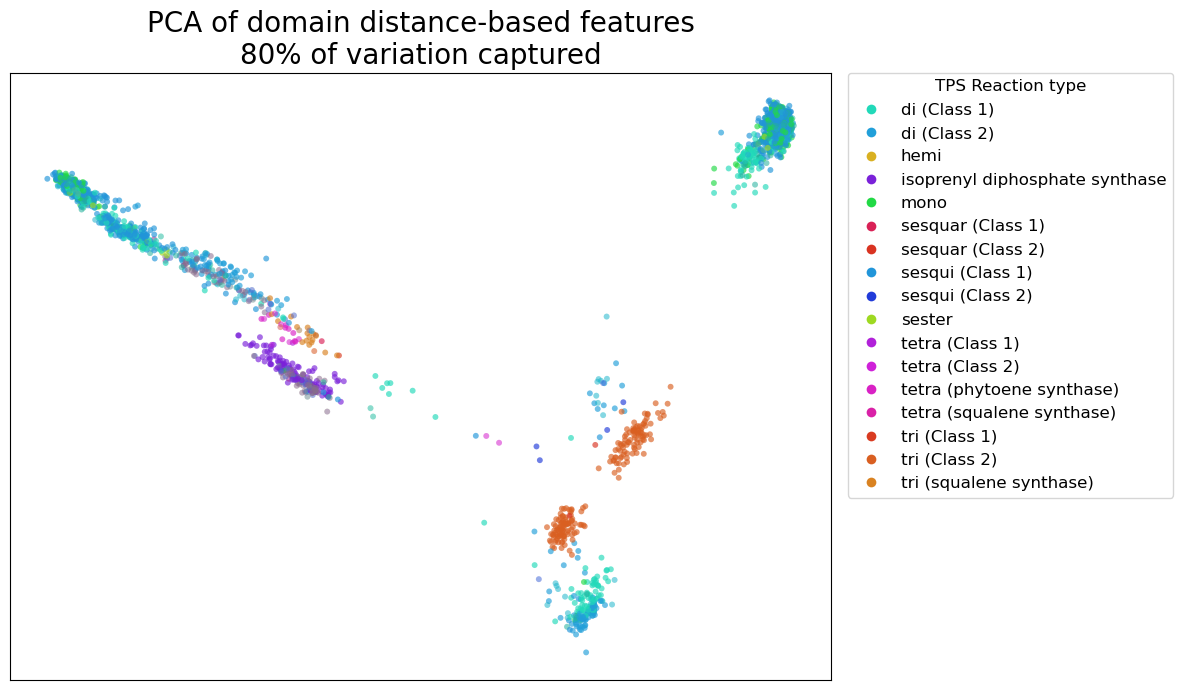

In [30]:
pca_coord_dom, explained_variance = get_pca_analysis(
    domains_dist_matrice,
    dom_reaction_types,
    reaction_types,
    title="PCA of domain distance-based features",
    legend_title="TPS Reaction type",
)

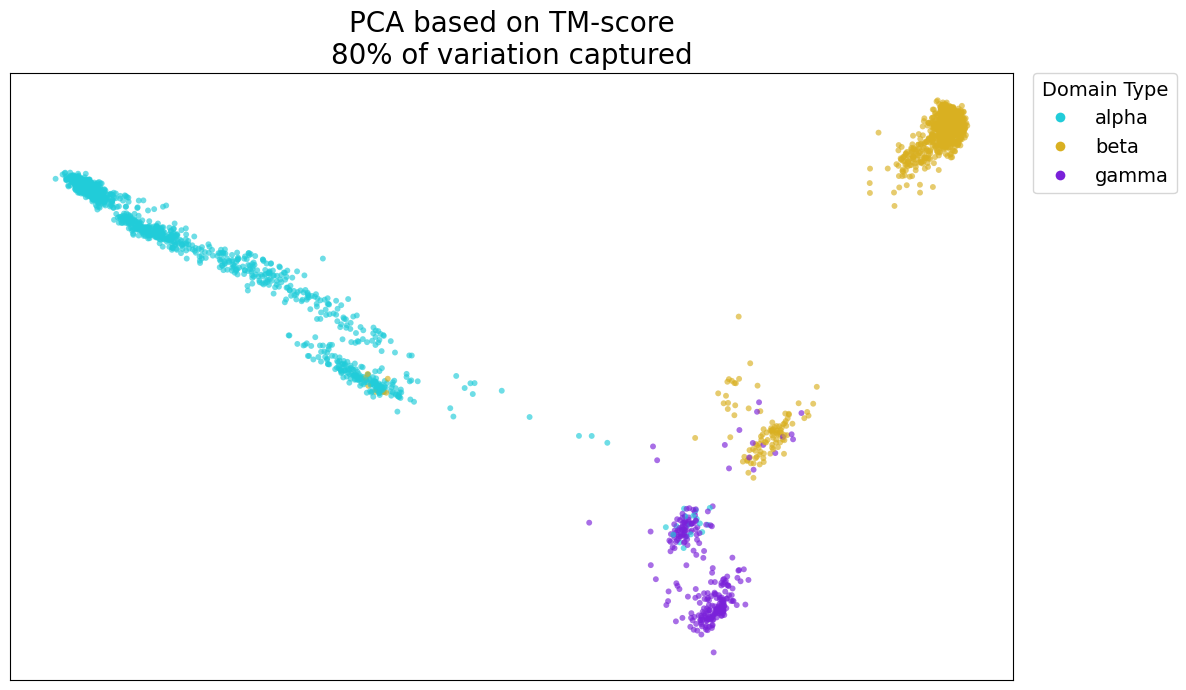

In [31]:
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    pca_coord_dom,
    domain_types,
    ["alpha", "beta", "gamma"],
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
)
plt.show()

## K-Medoid Clustering

  0%|          | 0/13 [00:00<?, ?it/s]

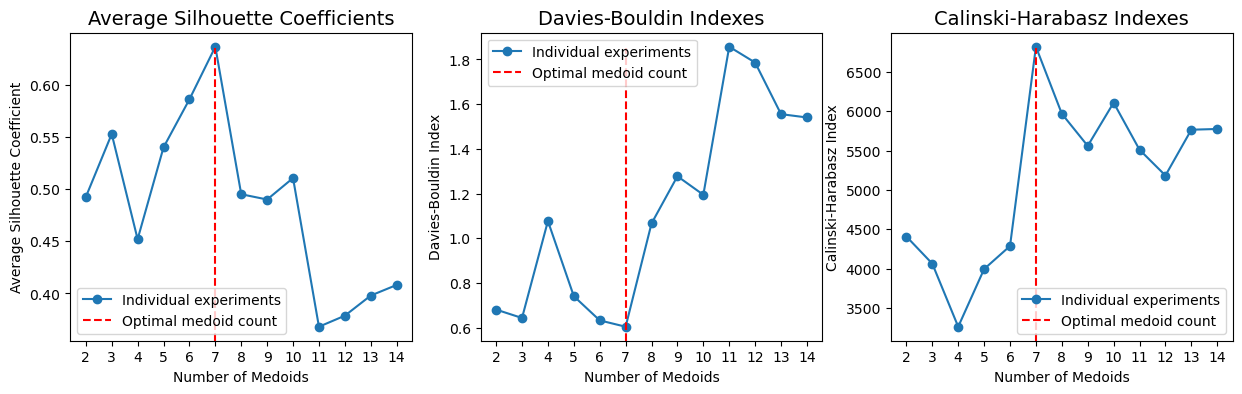

In [32]:
max_range = 15
km_s, silhouette_avg_all, davies_bouldin_all, calinski_harabasz_all = (
    get_k_medoid_clustering(domains_dist_matrice)
)
n_medoids_best = plot_optimal_num_medoid_selection(
    silhouette_avg_all, davies_bouldin_all, calinski_harabasz_all
)
km = km_s[n_medoids_best - 2]
cluster_labels = km.labels_
    
cluster_label_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(cluster_labels, domain_types)
domain_subtypes = [cluster_label_2_domain_subtype[l] for l in cluster_labels]
pairwise_closest_domains_after_clustering = get_pairwise_closest_domains(domain_subtypes, domains_dist_matrice)

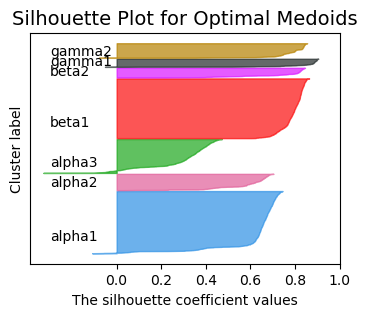

In [33]:
plot_silhouette_analysis(domains_dist_matrice, np.array([cluster_label_2_domain_subtype[l] for l in cluster_labels]))

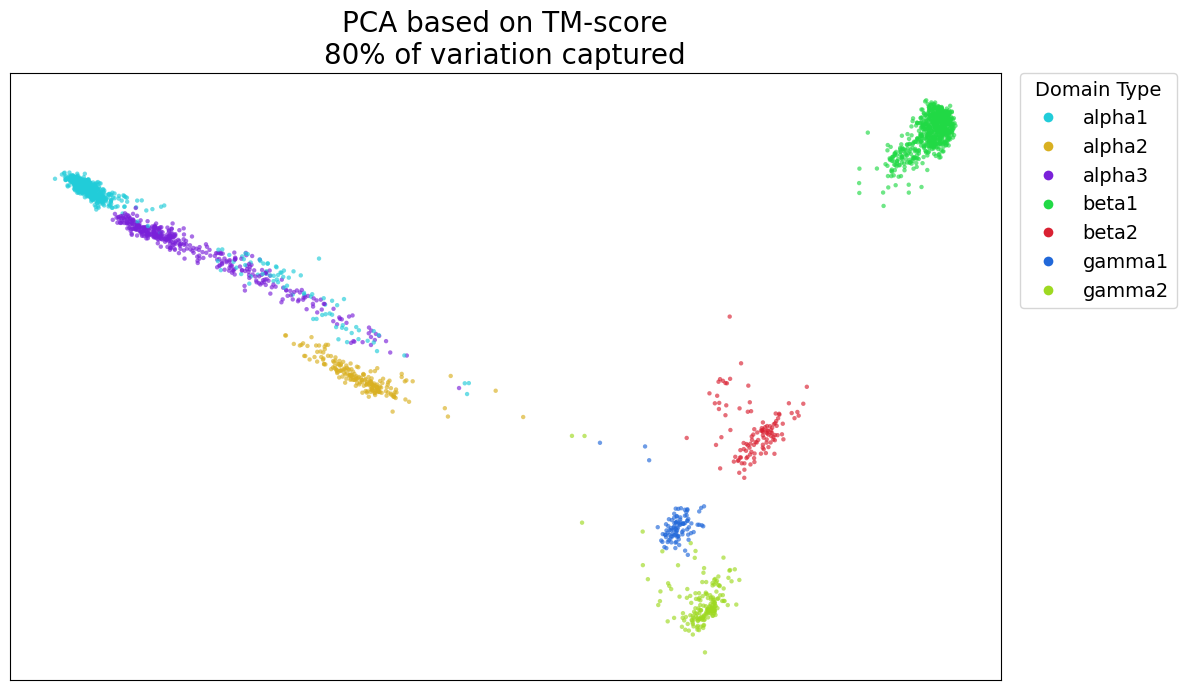

In [34]:
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    pca_coord_dom,
    domain_subtypes,
    sorted(cluster_label_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
    marker_size=10,
    # markings=[(module_idx, domains[module_idx]) for module_idx in pairwise_closest_domains_after_clustering[("beta1", "gamma1")][:5]],
)
plt.show()

# Clustering Using Final Domain Detection

## Initialization

In [92]:
alignment_results_dir = "../data/martsDB_structural_features/"
foldseek_tmscores = pickle.load(open(alignment_results_dir + "precomputed_tmscores_foldseek.pkl", "rb"))
seq_id_2_domains = pickle.load(open(alignment_results_dir + "preprocessed_reference_seq_2_regions.pkl", "rb"))

In [11]:
tps_ids_with_detected_domains = set(seq_id_2_domains.keys())

assert set(martsDB.Enzyme_marts_ID.values).issuperset(tps_ids_with_detected_domains), "There are some TPSs with detected domains that are not in the martsDB. This should not happen."

martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(tps_ids_with_detected_domains)]

id_2_substrates_set = martsDB.groupby("Enzyme_marts_ID")[
    "SMILES_substrate_canonical_no_stereo"
].agg(set)
id_2_type_set = martsDB.groupby("Enzyme_marts_ID")["reaction_type"].agg(set)
tps_ids = set(martsDB['Enzyme_marts_ID'].values)
domain_2_tps_id = {
    domain.module_id: seq_id
    for seq_id, domains in seq_id_2_domains.items()
    for domain in domains
}
domain_2_domain_type = {
    domain.module_id: domain.domain
    for _, domains in seq_id_2_domains.items()
    for domain in domains
}
module_id_to_region = {
    domain.module_id: domain
    for _, domains in seq_id_2_domains.items()
    for domain in domains
}
domains = sorted(list(domain_2_tps_id.keys()))
domain_regions = [module_id_to_region[dom] for dom in domains]
dom_2_idx = {dom: i for i,dom in enumerate(domains)}

domains_dist_matrice = np.zeros((len(domains), len(domains)))
for ((dom_i, dom_j), tmscore) in foldseek_tmscores.items():
    dom_i_idx = dom_2_idx[dom_i]
    dom_j_idx = dom_2_idx[dom_j]
    domains_dist_matrice[dom_i_idx, dom_j_idx] = tmscore
    domains_dist_matrice[dom_j_idx, dom_i_idx] = tmscore
domains_dist_matrice = 1 - domains_dist_matrice
np.fill_diagonal(domains_dist_matrice, 0)

dom_2_idx = {dom: i for i,dom in enumerate(domains)}

dom_seq_ids = [domain_2_tps_id[dom] for dom in domains]
reaction_types = sorted(martsDB.reaction_type.unique())
dom_reaction_types = [id_2_type_set[seq_id] for seq_id in dom_seq_ids]

domain_types = [dom.split("_")[-2] for dom in domains]


## Domain Type Analysis

### PCA with TPS reaction type labels

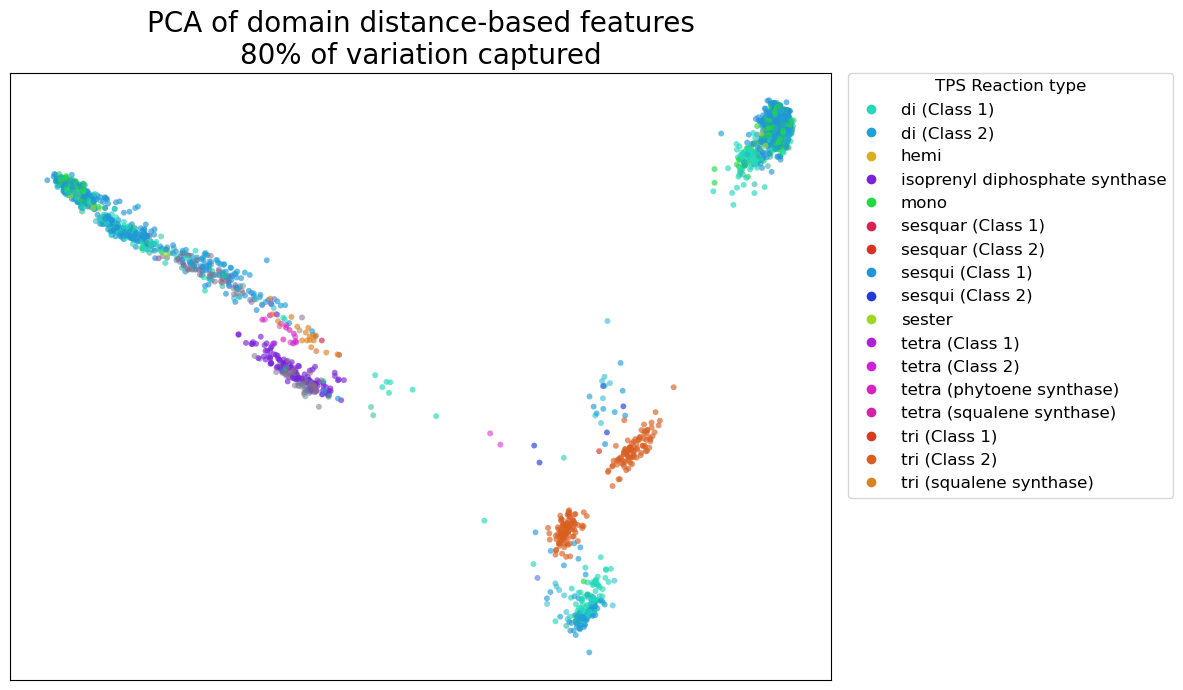

In [37]:
pca_coord_dom, explained_variance = get_pca_analysis(
    domains_dist_matrice,
    dom_reaction_types,
    reaction_types,
    title="PCA of domain distance-based features",
    legend_title="TPS Reaction type",
)

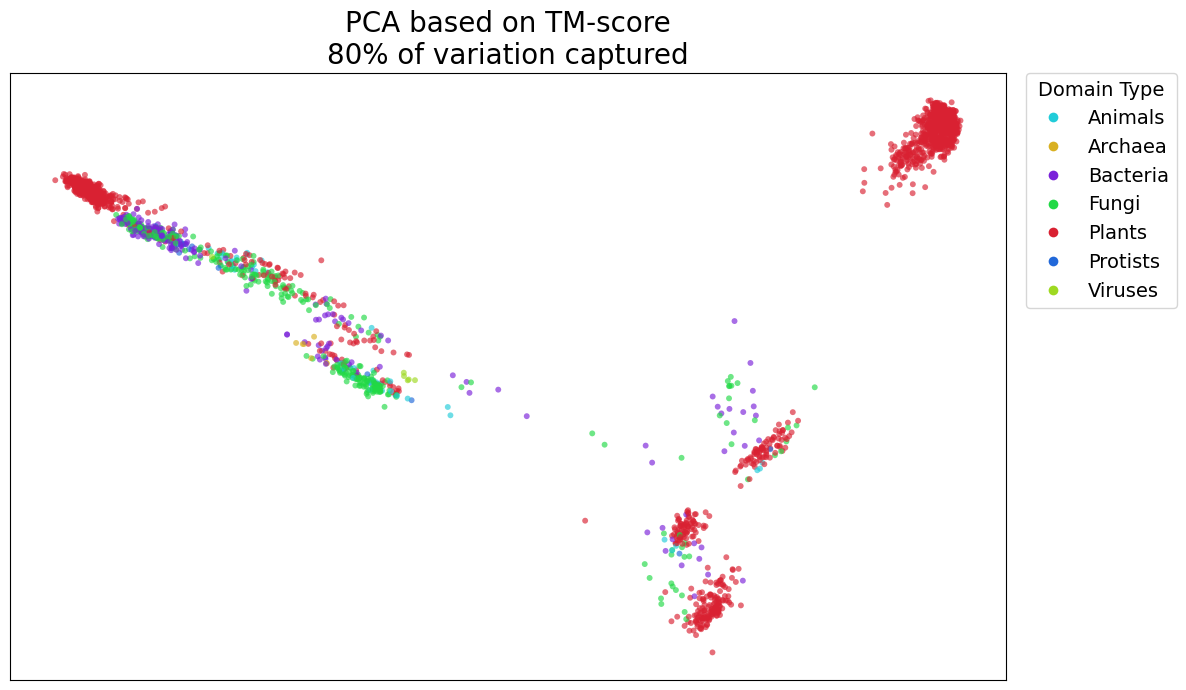

In [38]:
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    pca_coord_dom,
    [seq_to_kingdom[domain_seq_id] for domain_seq_id in dom_seq_ids],
    list(set([seq_to_kingdom[domain_seq_id] for domain_seq_id in dom_seq_ids])),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
    # markings=[(module_idx, domains[module_idx]) for module_idx in pairwise_closest_domains[("gamma", "epsilon")][:5]],
)
plt.show()

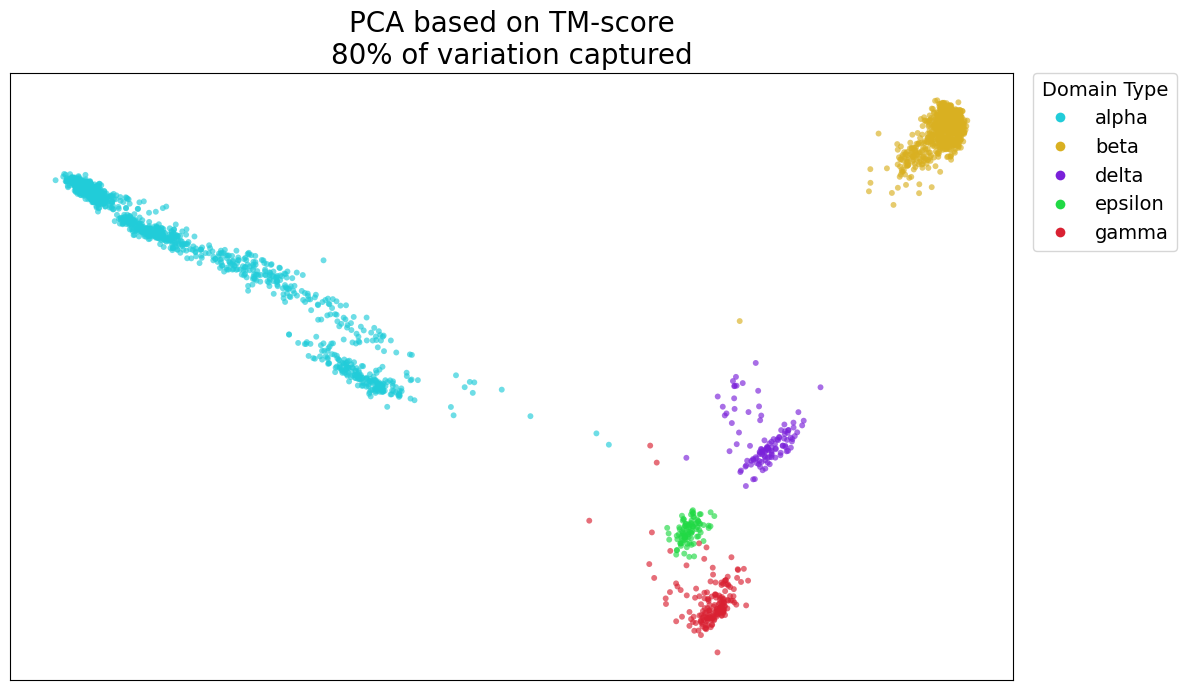

In [39]:
pairwise_closest_domains = get_pairwise_closest_domains(domain_types, domains_dist_matrice)
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    pca_coord_dom,
    domain_types,
    ["alpha", "beta", "gamma", "delta", "epsilon"],
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
    # markings=[(module_idx, domains[module_idx]) for module_idx in pairwise_closest_domains[("gamma", "alpha")][130:180]],
)
plt.show()

### K-Medoid Clustering

  0%|          | 0/13 [00:00<?, ?it/s]

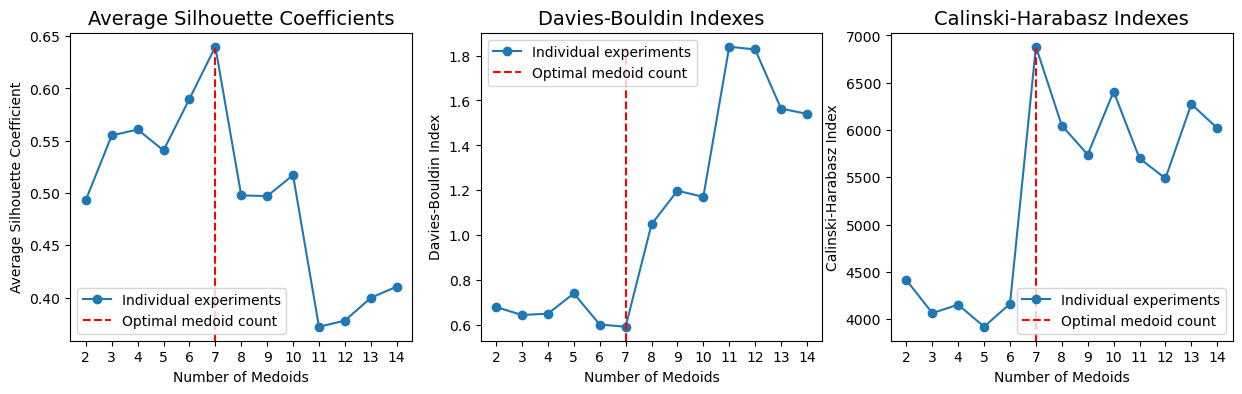

In [40]:
km_s, silhouette_avg_all, davies_bouldin_all, calinski_harabasz_all = (
    get_k_medoid_clustering(domains_dist_matrice)
)
n_medoids_best = plot_optimal_num_medoid_selection(
    silhouette_avg_all, davies_bouldin_all, calinski_harabasz_all
)
km = km_s[n_medoids_best - 2]
cluster_labels = km.labels_
    
cluster_label_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(cluster_labels, domain_types)
domain_subtypes = [cluster_label_2_domain_subtype[l] for l in cluster_labels]

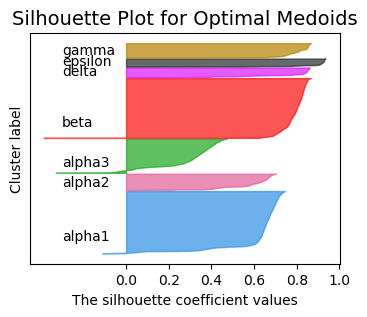

In [41]:
plot_silhouette_analysis(domains_dist_matrice, np.array([cluster_label_2_domain_subtype[l] for l in cluster_labels]))

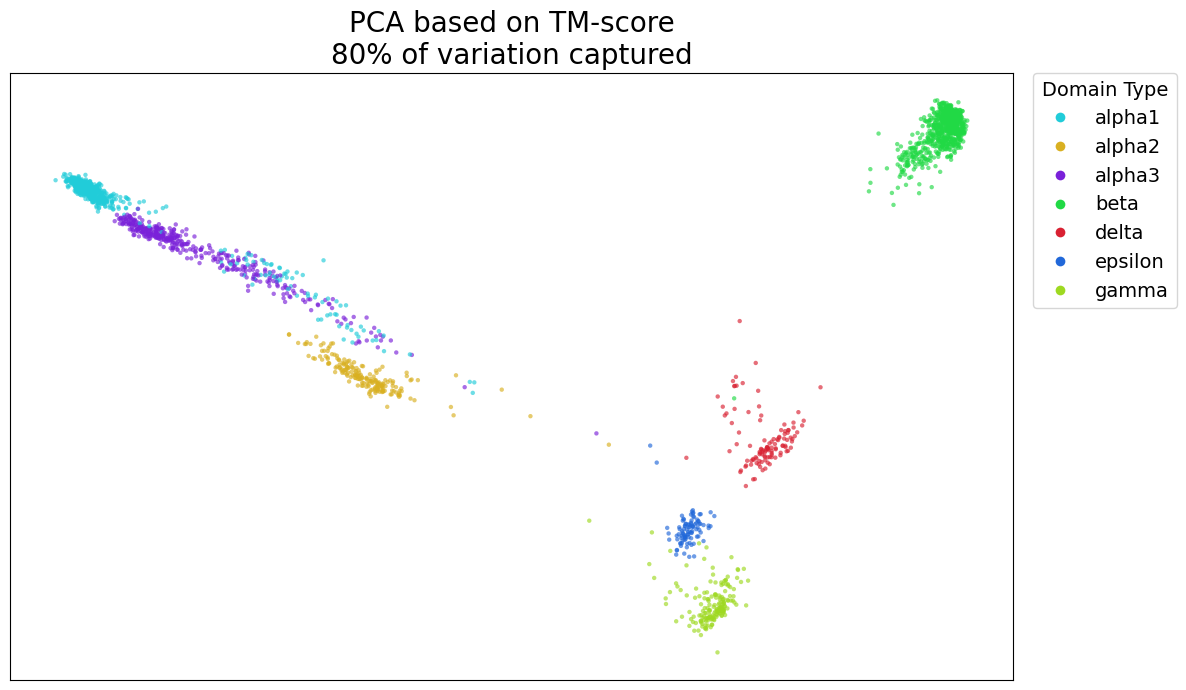

In [42]:
pairwise_closest_domains_after_clustering = get_pairwise_closest_domains(domain_subtypes, domains_dist_matrice)
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    pca_coord_dom,
    domain_subtypes,
    sorted(cluster_label_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
    marker_size=10,
    # markings=[(module_idx, domains[module_idx]) for module_idx in pairwise_closest_domains_after_clustering[("alpha1", "alpha2")][:5]],
)
plt.show()

### HDBSCAN Clustering

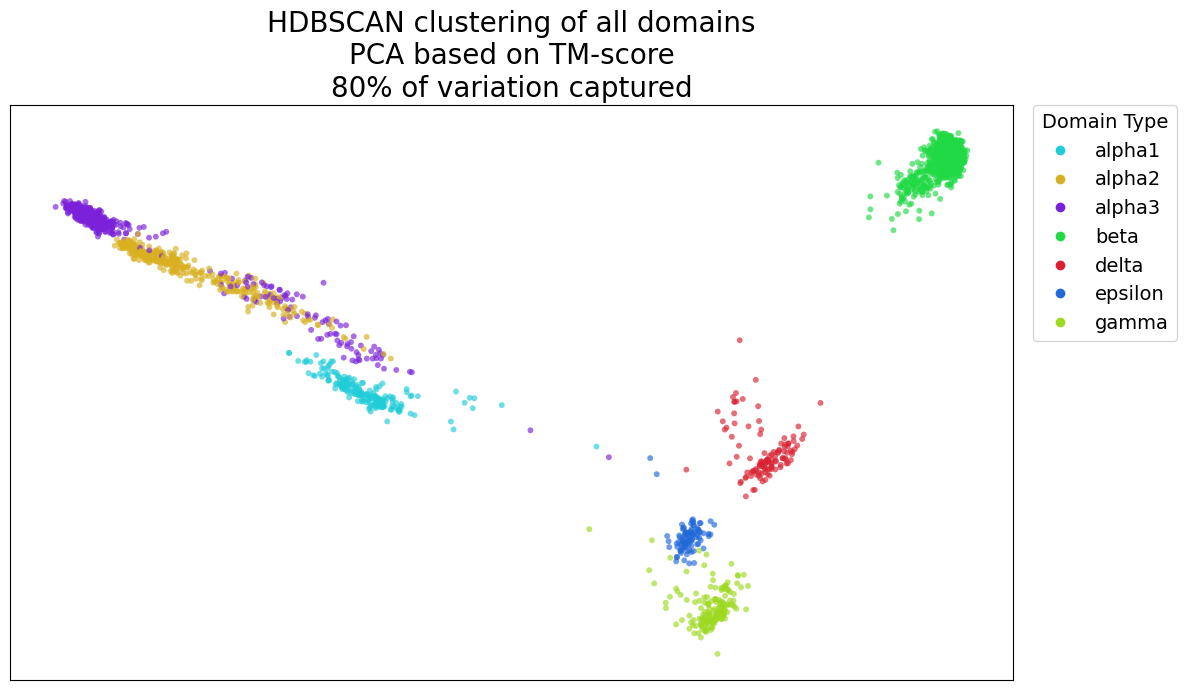

In [43]:
hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=50
)  # , min_cluster_size=10)
hdbscan_clusterer.fit(domains_dist_matrice)

fill_noise_with_closest_label(
    hdbscan_clusterer.labels_, domains_dist_matrice, n_neighbs=20
)

hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    hdbscan_clusterer.labels_, domain_types
)

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    pca_coord_dom,
    [{hdbscan_cluster_id_2_domain_subtype[l]} for l in hdbscan_clusterer.labels_],
    sorted(hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all domains\nPCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
)
plt.show()

## Non-Alpha Domain Subtype Analysis

In [44]:
non_alpha_idxs = [i for i, label in enumerate(domain_types) if label != "alpha"]
non_alpha_dist_matrice = domains_dist_matrice[non_alpha_idxs, :][:, non_alpha_idxs]
non_alpha_domains = [domains[i] for i in non_alpha_idxs]
non_alpha_domain_types = [domain_types[i] for i in non_alpha_idxs]
non_alpha_reaction_types = [dom_reaction_types[i] for i in non_alpha_idxs]
non_alpha_sequences = [dom_seq_ids[i] for i in non_alpha_idxs]
non_alpha_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(non_alpha_sequences)]
non_alpha_reaction_types_all = non_alpha_martsDB.reaction_type.unique()

### PCA Analysis

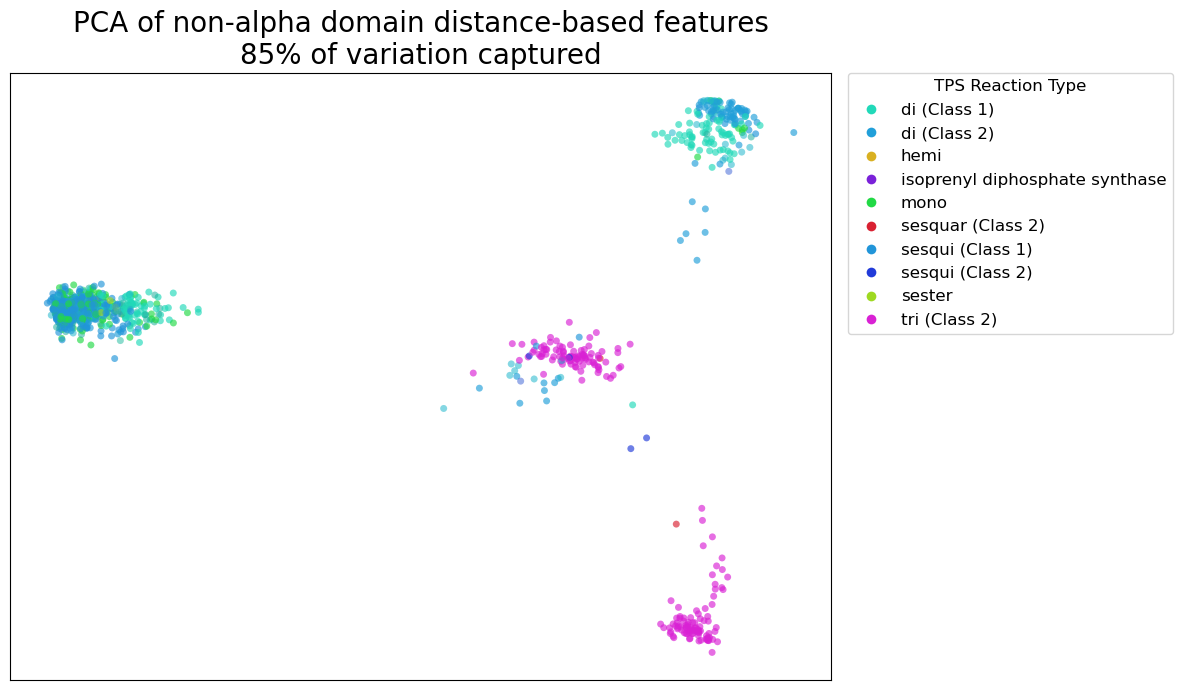

In [45]:
non_alpha_pca_coord_dom, non_alpha_explained_variance = get_pca_analysis(
    non_alpha_dist_matrice,
    non_alpha_reaction_types,
    non_alpha_reaction_types_all,
    title="PCA of non-alpha domain distance-based features",
    legend_title="TPS Reaction Type",
    marker_size=25,
)


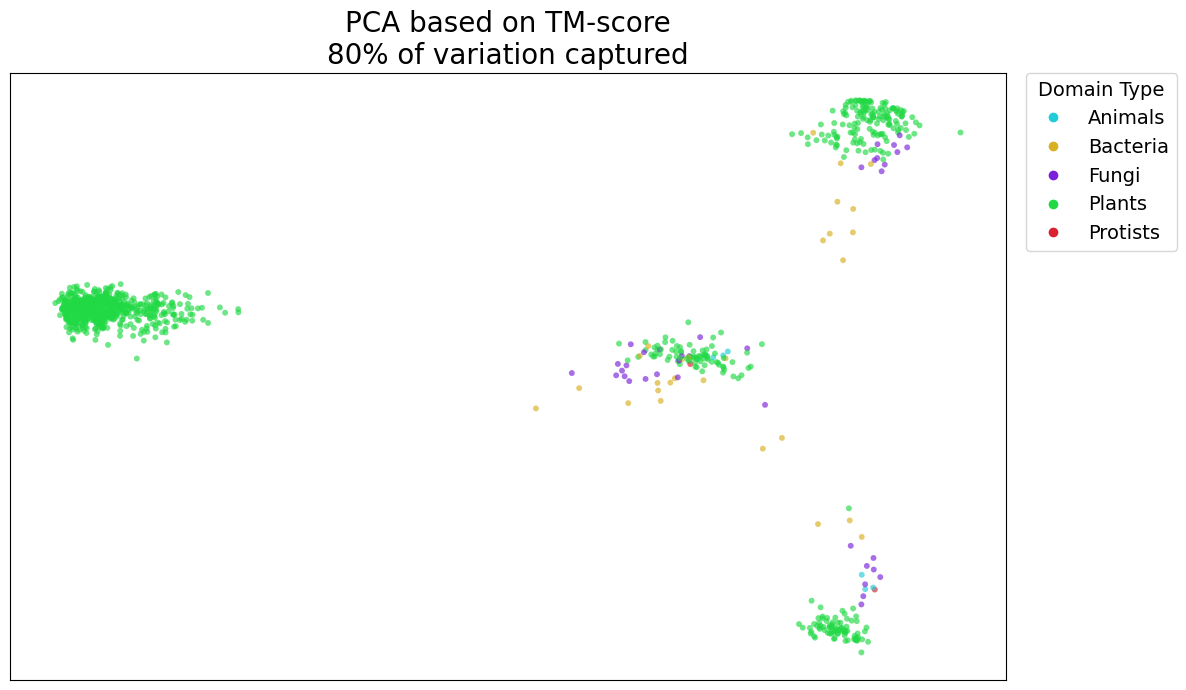

In [46]:
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    non_alpha_pca_coord_dom,
    [seq_to_kingdom[domain_seq_id] for domain_seq_id in non_alpha_sequences],
    list(set([seq_to_kingdom[domain_seq_id] for domain_seq_id in non_alpha_sequences])),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
    # markings=[(module_idx, domains[module_idx]) for module_idx in pairwise_closest_domains[("gamma", "epsilon")][:5]],
)
plt.show()

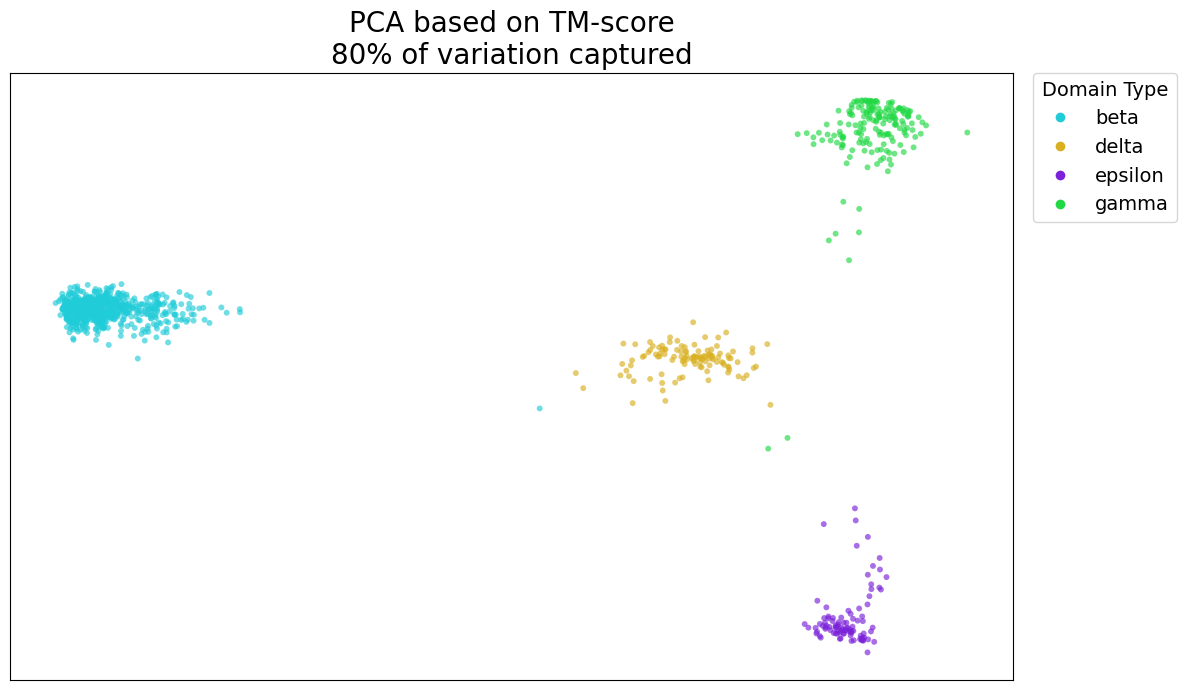

In [47]:
non_alpha_pairwise_closest_domains = get_pairwise_closest_domains(non_alpha_domain_types, non_alpha_dist_matrice)
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    non_alpha_pca_coord_dom,
    non_alpha_domain_types,
    ["beta", "gamma", "delta", "epsilon"],
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
    # markings=[(module_idx, non_alpha_domains[module_idx]) for module_idx in non_alpha_pairwise_closest_domains[("gamma", "beta")][:3]],
)
plt.show()

### K-Medoid Clustering

  0%|          | 0/18 [00:00<?, ?it/s]

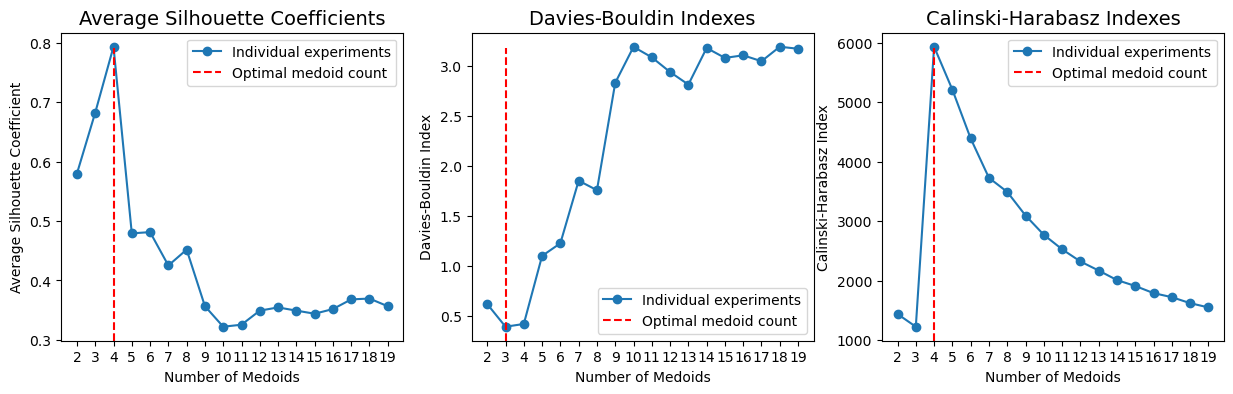

In [48]:
max_range = 20
non_alpha_km_s, non_alpha_silhouette_avg_all, non_alpha_davies_bouldin_all, non_alpha_calinski_harabasz_all = (
    get_k_medoid_clustering(non_alpha_dist_matrice, max_range=max_range)
)
non_alpha_n_medoids_best = plot_optimal_num_medoid_selection(
    non_alpha_silhouette_avg_all, non_alpha_davies_bouldin_all, non_alpha_calinski_harabasz_all, max_range=max_range
)
non_alpha_km = non_alpha_km_s[non_alpha_n_medoids_best - 2]
non_alpha_cluster_labels = non_alpha_km.labels_
non_alpha_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(non_alpha_cluster_labels, non_alpha_domain_types)
non_alpha_new_domains = [non_alpha_cluster_id_2_domain_subtype[l] for l in non_alpha_cluster_labels]


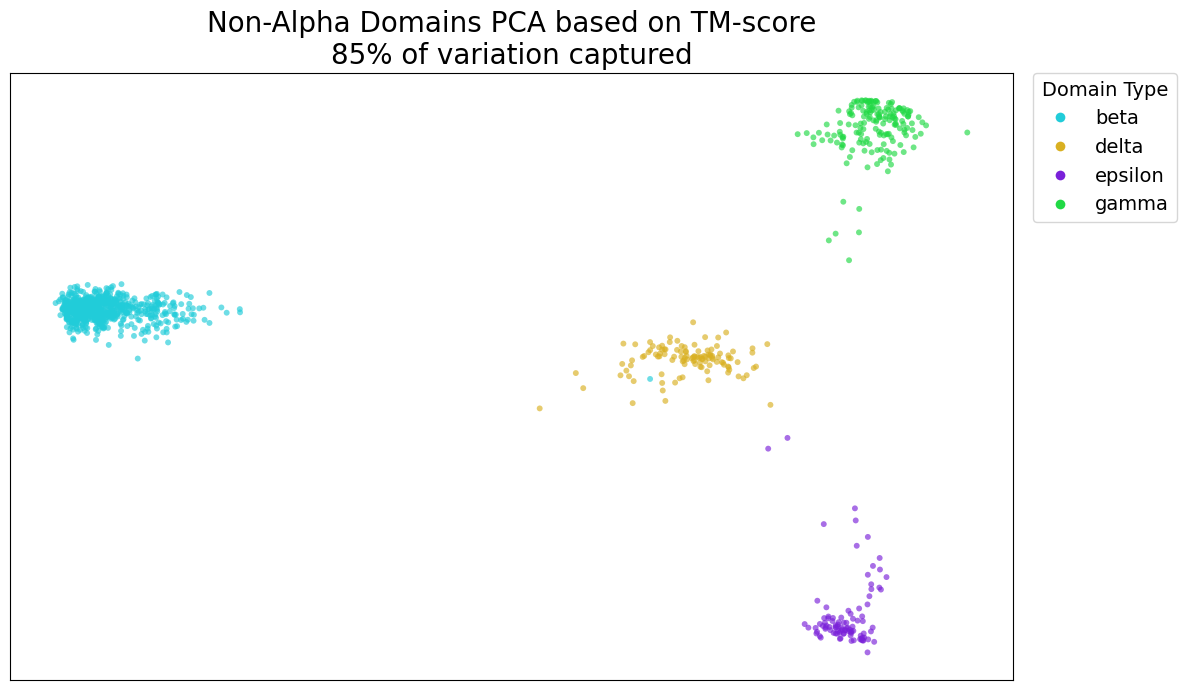

In [49]:
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    non_alpha_pca_coord_dom,
    non_alpha_new_domains,
    sorted(non_alpha_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Non-Alpha Domains PCA based on TM-score\n{sum(non_alpha_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

### HDBSCAN Clustering

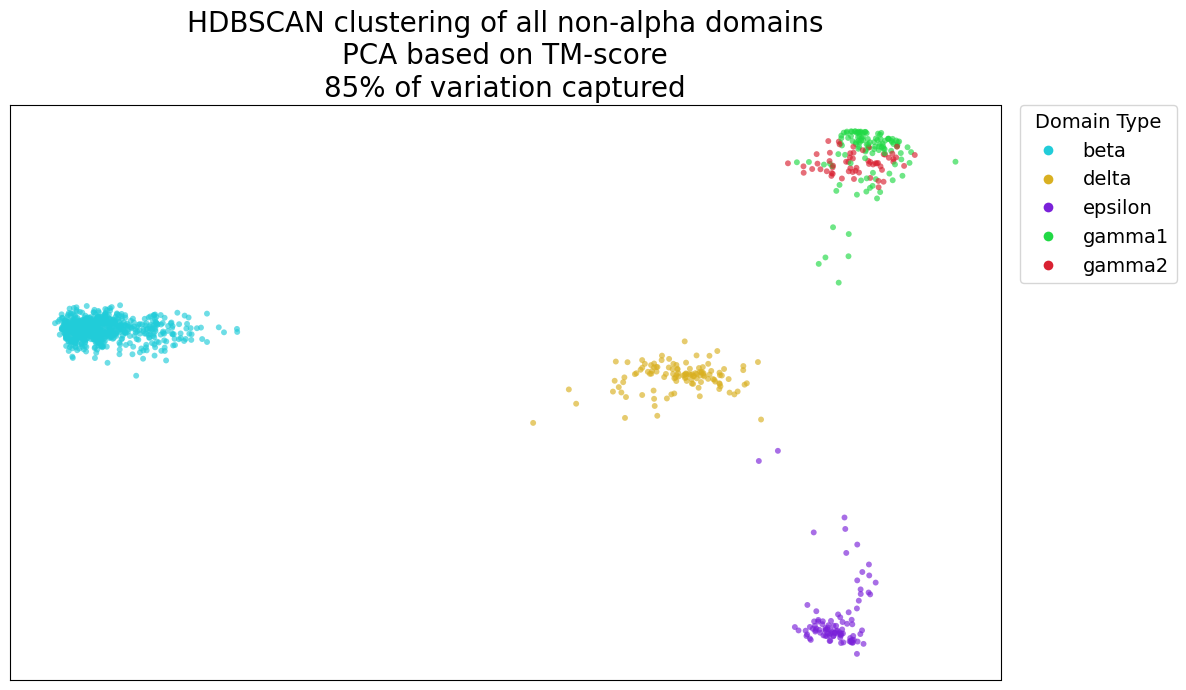

In [50]:
non_alpha_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=15
)  # , min_cluster_size=10)
non_alpha_hdbscan_clusterer.fit(non_alpha_dist_matrice)

fill_noise_with_closest_label(
    non_alpha_hdbscan_clusterer.labels_, non_alpha_dist_matrice, n_neighbs=11
)

non_alpha_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    non_alpha_hdbscan_clusterer.labels_, non_alpha_domain_types
)

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    non_alpha_pca_coord_dom,
    [{non_alpha_hdbscan_cluster_id_2_domain_subtype[l]} for l in non_alpha_hdbscan_clusterer.labels_],
    sorted(non_alpha_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all non-alpha domains\nPCA based on TM-score\n{sum(non_alpha_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

## Gamma Domain Subtype Analysis

In [51]:
gamma_clusters_ids = set([i for i,domain_subtype in cluster_label_2_domain_subtype.items() if "gamma" in domain_subtype])
gamma_idxs = [i for i, label in enumerate(km.labels_) if label in gamma_clusters_ids]
gamma_dist_matrice = domains_dist_matrice[gamma_idxs, :][:, gamma_idxs]
gamma_domains = [domains[i] for i in gamma_idxs]
gamma_domain_types = [cluster_label_2_domain_subtype[cluster_labels[i]] for i in gamma_idxs]
gamma_reaction_types = [dom_reaction_types[i] for i in gamma_idxs]
gamma_sequences = [dom_seq_ids[i] for i in gamma_idxs]
gamma_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(gamma_sequences)]
gamma_reaction_types_all = gamma_martsDB.reaction_type.unique()

### PCA Analysis

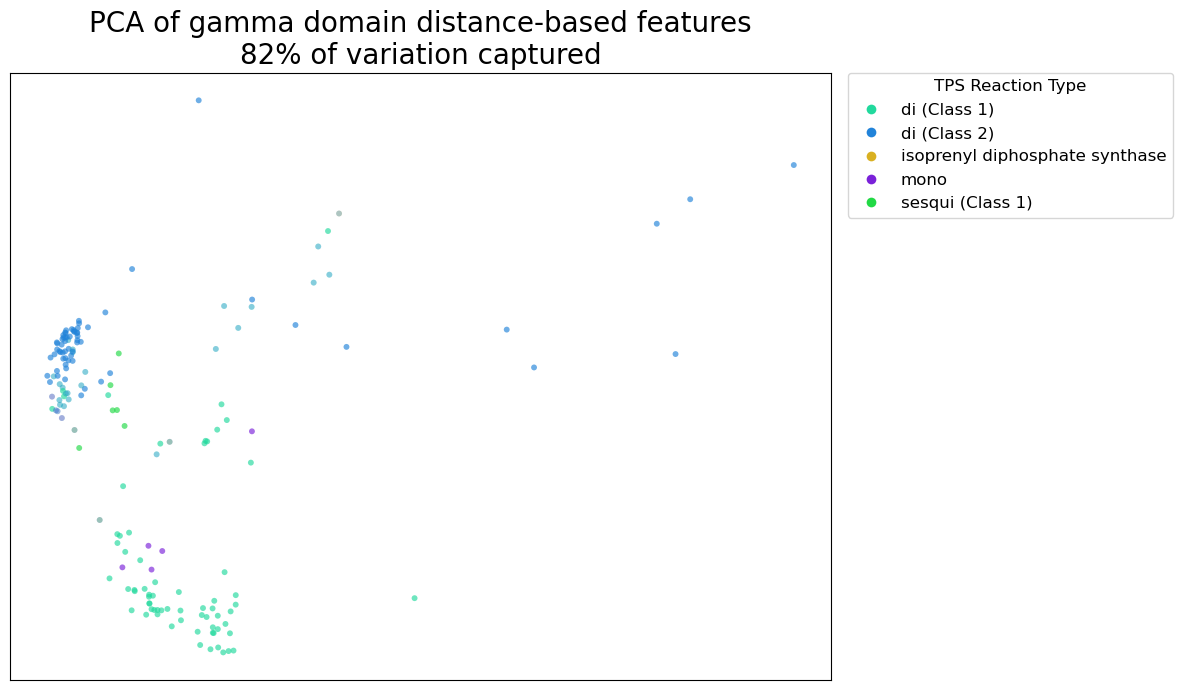

In [52]:
gamma_pca_coord_dom, gamma_explained_variance = get_pca_analysis(
    gamma_dist_matrice,
    gamma_reaction_types,
    gamma_reaction_types_all,
    title="PCA of gamma domain distance-based features",
    legend_title="TPS Reaction Type",
    # markings=[(module_idx, gamma_domains[module_idx]) for module_idx, rxn_type in enumerate(gamma_reaction_types) if "di (Class 2)" in rxn_type][5:10],
)


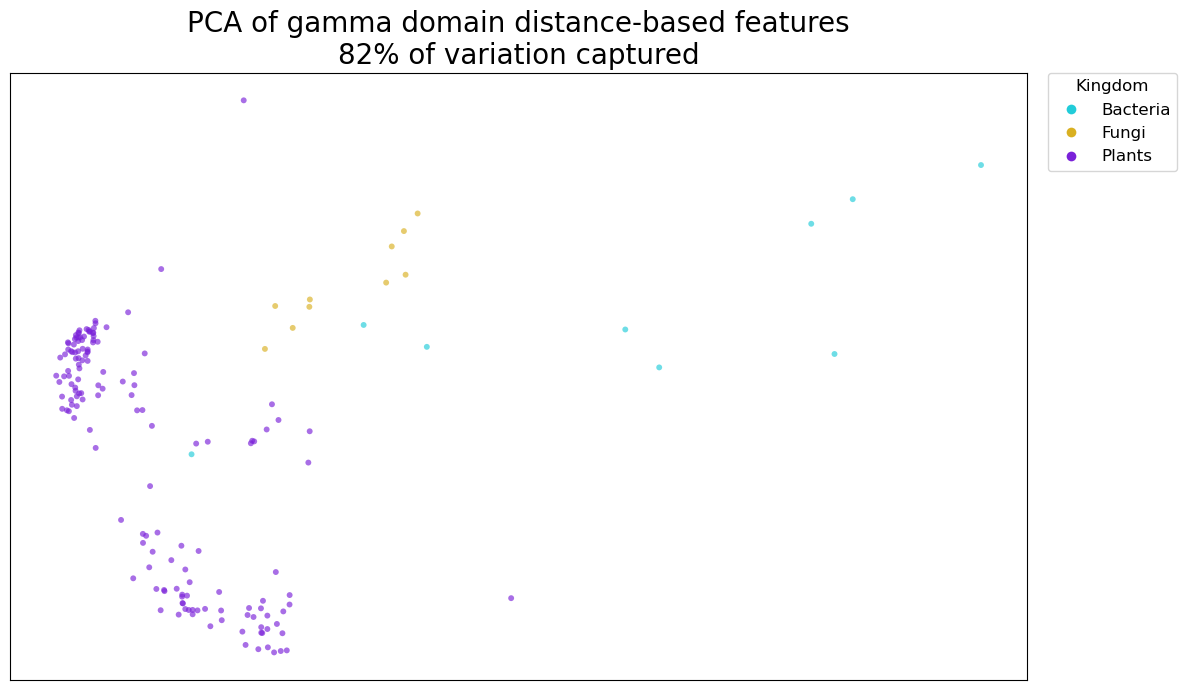

In [53]:
gamma_pca_coord_dom, gamma_explained_variance = get_pca_analysis(
    gamma_dist_matrice,
    [seq_to_kingdom[seq_id] for seq_id in gamma_sequences],
    list(set([seq_to_kingdom[seq_id] for seq_id in gamma_sequences])),
    title="PCA of gamma domain distance-based features",
    legend_title="Kingdom",
)

### K-Medoid Clustering

  0%|          | 0/6 [00:00<?, ?it/s]

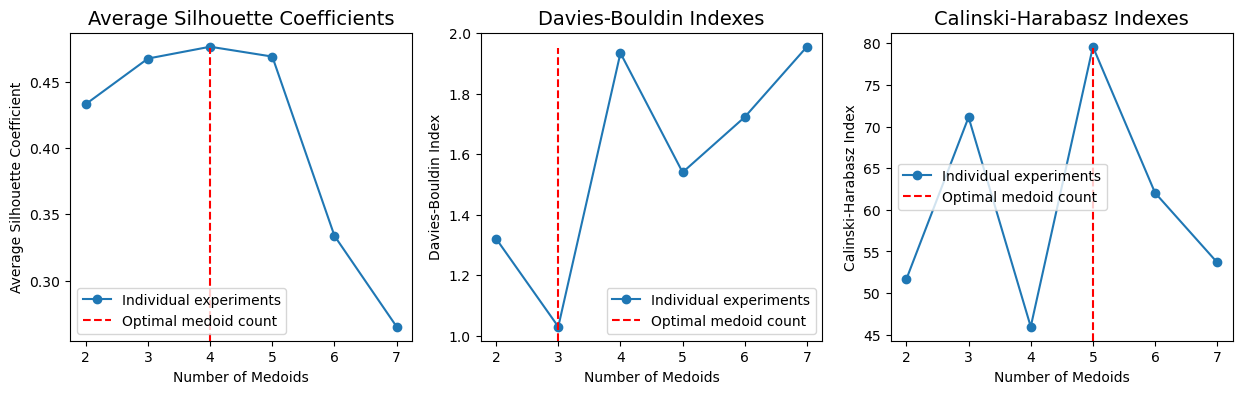

In [54]:
max_range = 8
gamma_km_s, gamma_silhouette_avg_all, gamma_davies_bouldin_all, gamma_calinski_harabasz_all = (
    get_k_medoid_clustering(gamma_dist_matrice, max_range=max_range)
)
gamma_n_medoids_best = plot_optimal_num_medoid_selection(
    gamma_silhouette_avg_all, gamma_davies_bouldin_all, gamma_calinski_harabasz_all, max_range
)
gamma_km = gamma_km_s[gamma_n_medoids_best - 2]
gamma_cluster_labels = gamma_km.labels_

gamma_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(gamma_cluster_labels, gamma_domain_types)
gamma_domain_subtypes = [gamma_cluster_id_2_domain_subtype[l] for l in gamma_cluster_labels]


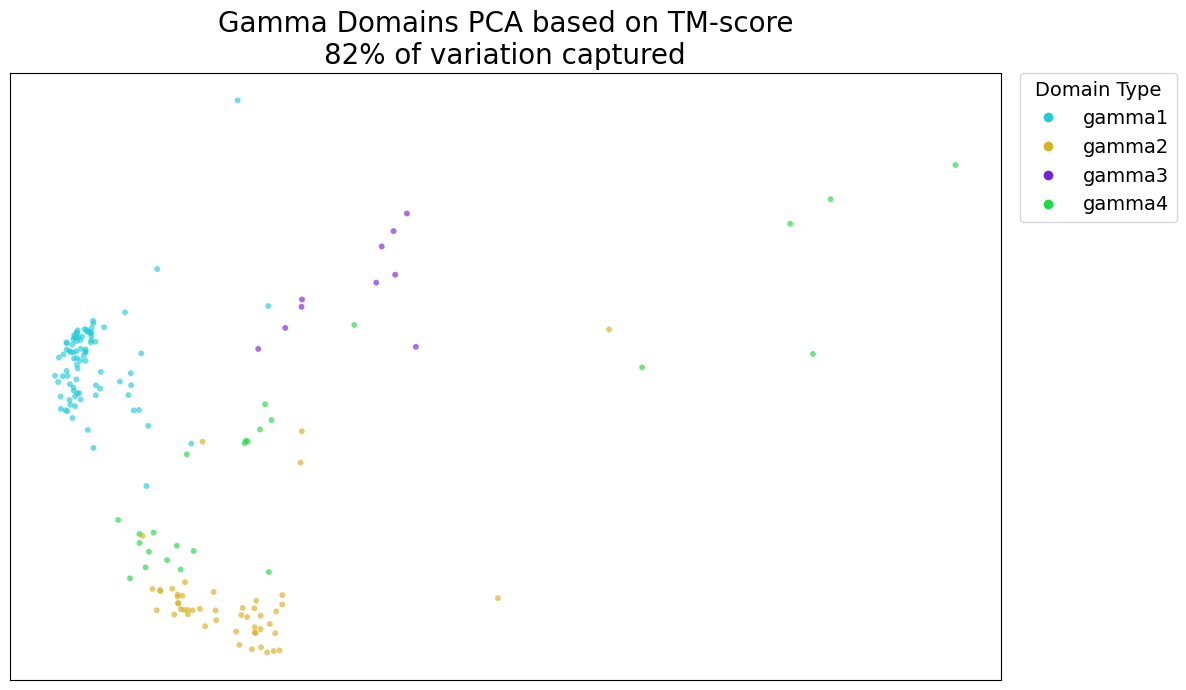

In [55]:
gamma_new_domains = [set([gamma_cluster_id_2_domain_subtype[l]]) for l in gamma_cluster_labels]
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    gamma_pca_coord_dom,
    gamma_domain_subtypes,
    sorted(gamma_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Gamma Domains PCA based on TM-score\n{sum(gamma_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

### HDBSCAN Clustering

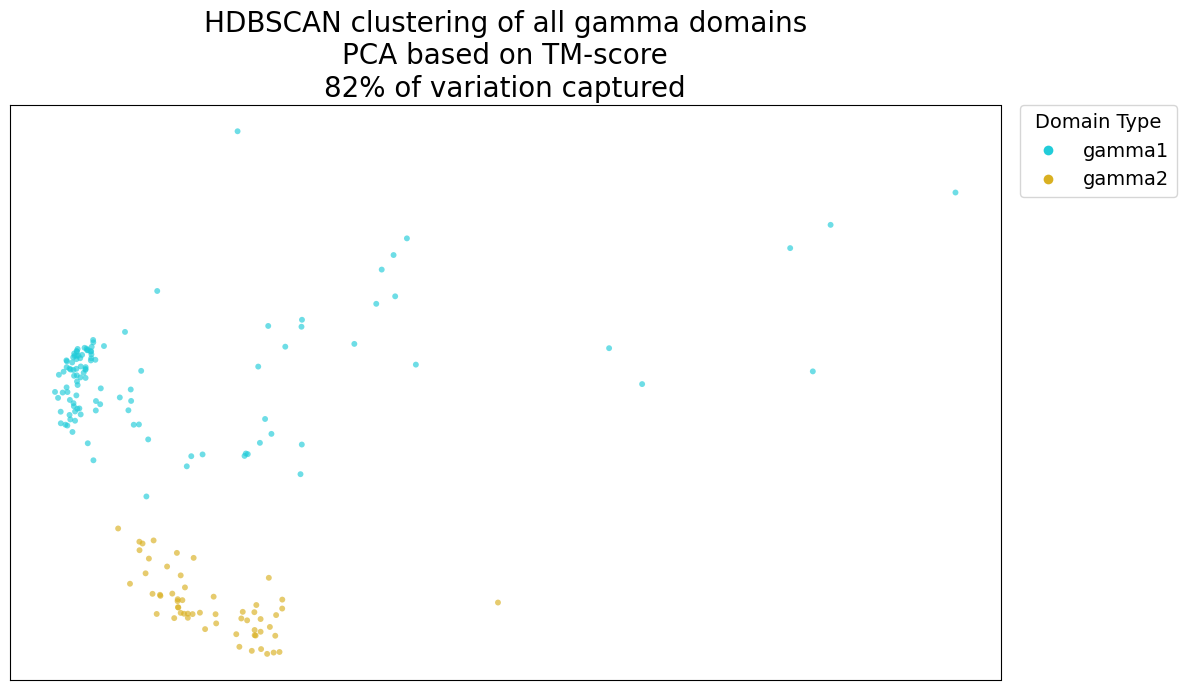

In [44]:
gamma_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=15
)  # , min_cluster_size=10)
gamma_hdbscan_clusterer.fit(gamma_dist_matrice)

fill_noise_with_closest_label(
    gamma_hdbscan_clusterer.labels_, gamma_dist_matrice, n_neighbs=11
)

gamma_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    gamma_hdbscan_clusterer.labels_, gamma_domain_types
)

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    gamma_pca_coord_dom,
    [{gamma_hdbscan_cluster_id_2_domain_subtype[l]} for l in gamma_hdbscan_clusterer.labels_],
    sorted(gamma_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all gamma domains\nPCA based on TM-score\n{sum(gamma_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

## Alpha Domain Subtype Analysis

In [12]:
alpha_idxs = [i for i, label in enumerate(domain_types) if label == "alpha"]
alpha_dist_matrice = domains_dist_matrice[alpha_idxs, :][:, alpha_idxs]
alpha_domains = [domains[i] for i in alpha_idxs]
alpha_domain_types = [domain_types[i] for i in alpha_idxs]
alpha_domain_original_types = [domain_regions[i].aligned_template for i in alpha_idxs]
alpha_reaction_types = [dom_reaction_types[i] for i in alpha_idxs]
alpha_sequences = [dom_seq_ids[i] for i in alpha_idxs]
alpha_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(alpha_sequences)]
alpha_reaction_types_all = alpha_martsDB.reaction_type.unique()

### PCA Analysis

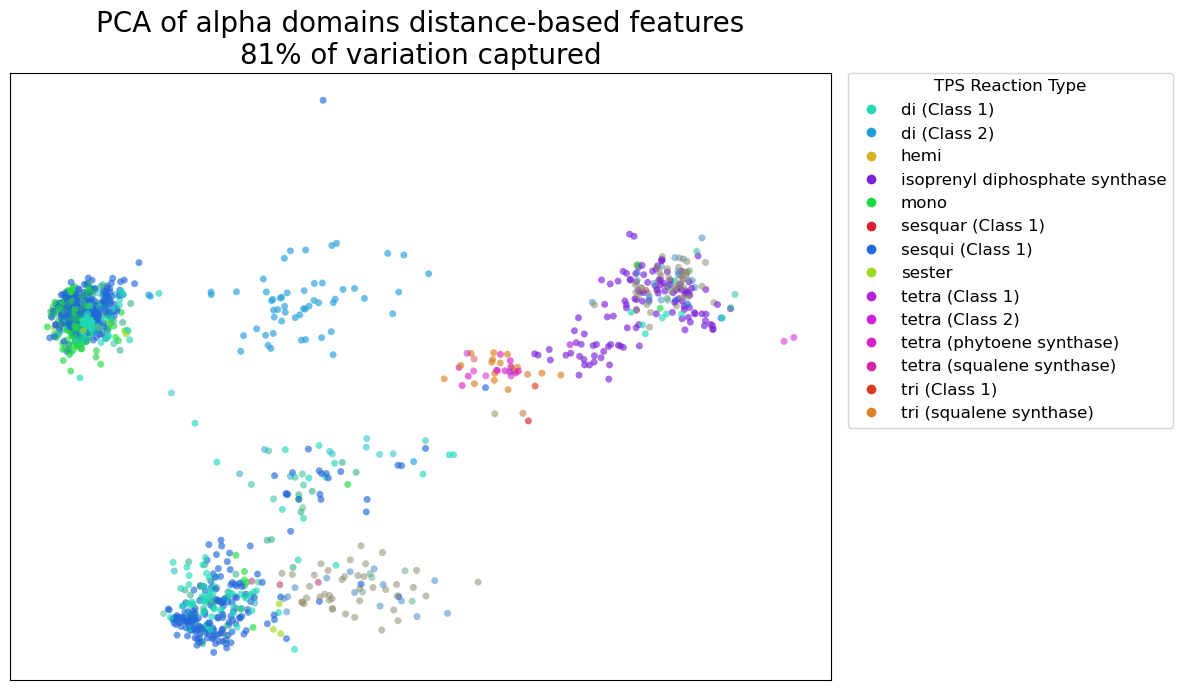

In [14]:
alpha_pca_coord_dom, alpha_explained_variance = get_pca_analysis(
    alpha_dist_matrice,
    alpha_reaction_types,
    alpha_reaction_types_all,
    title="PCA of alpha domains distance-based features",
    legend_title="TPS Reaction Type",
    marker_size=25,
    # markings=[(module_idx, alpha_domains[module_idx]) for module_idx, rxn_type in enumerate(alpha_reaction_types) if alpha_domains[module_idx] == "marts_E01065_alpha_0"],
)


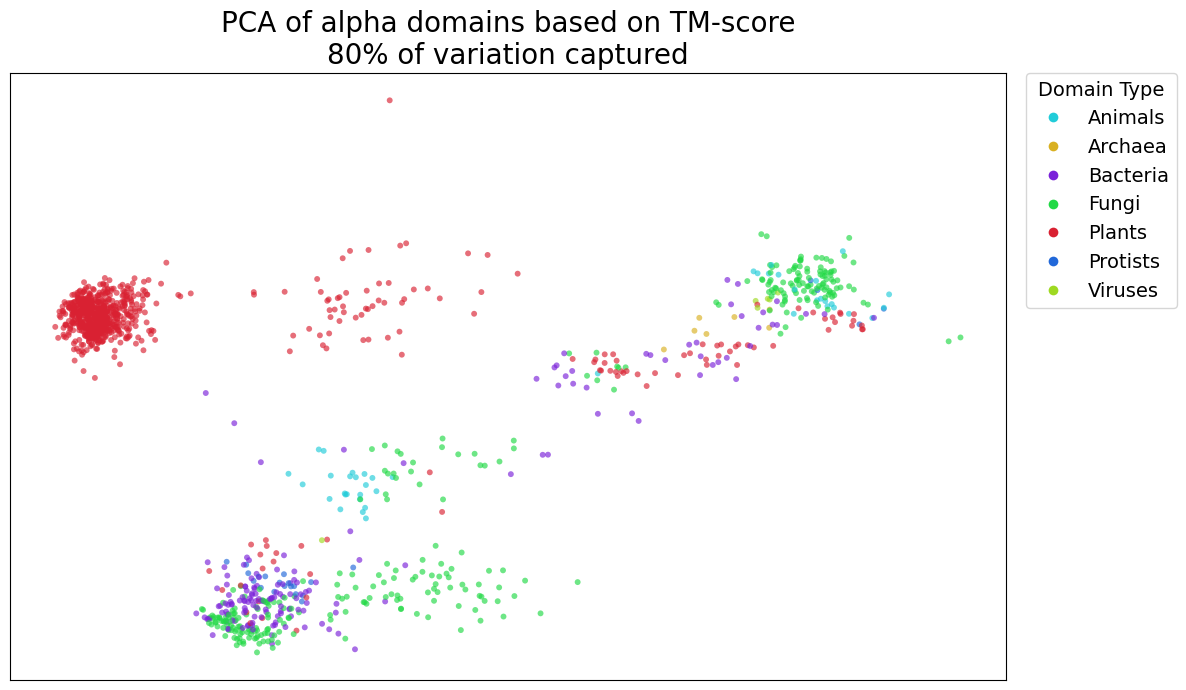

In [58]:
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha_pca_coord_dom,
    [seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha_sequences],
    list(set([seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha_sequences])),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA of alpha domains based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
)
plt.show()

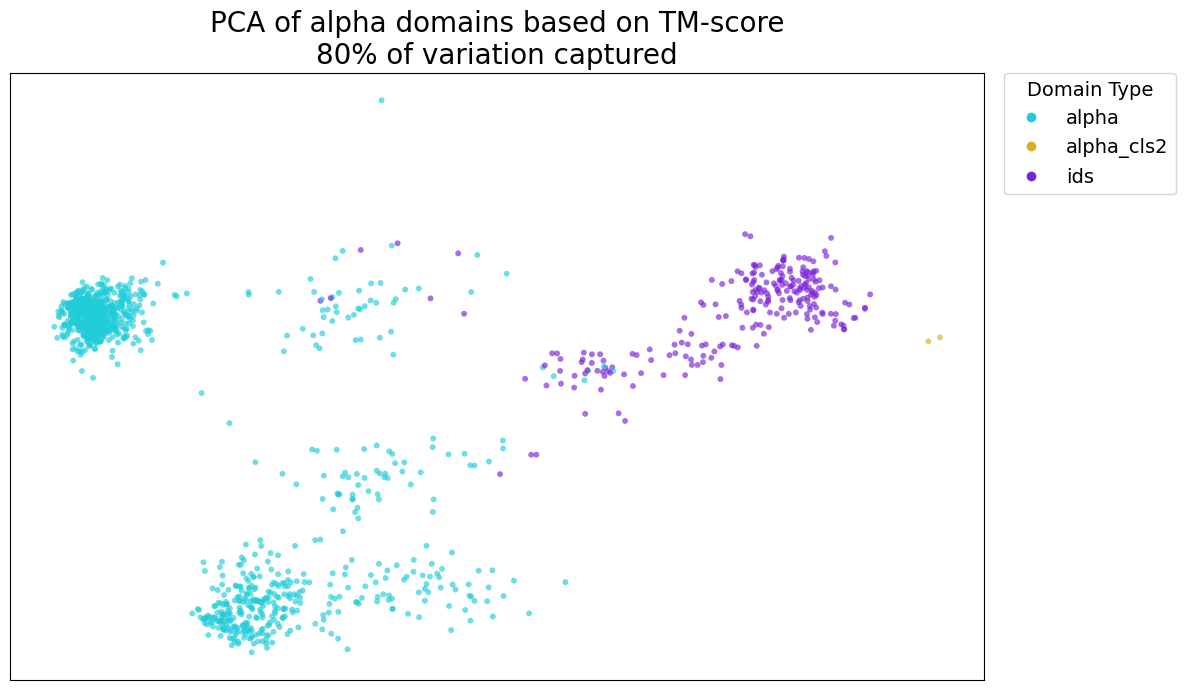

In [59]:
alpha_pairwise_closest_domains = get_pairwise_closest_domains(alpha_domain_original_types, alpha_dist_matrice)
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha_pca_coord_dom,
    alpha_domain_original_types,
    set(alpha_domain_original_types),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA of alpha domains based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
    # markings=[(module_idx, alpha_domains[module_idx]) for module_idx in alpha_pairwise_closest_domains[("ids", "alpha")][:15]],
)
plt.show()

### K-Medoid Clustering

  0%|          | 0/8 [00:00<?, ?it/s]

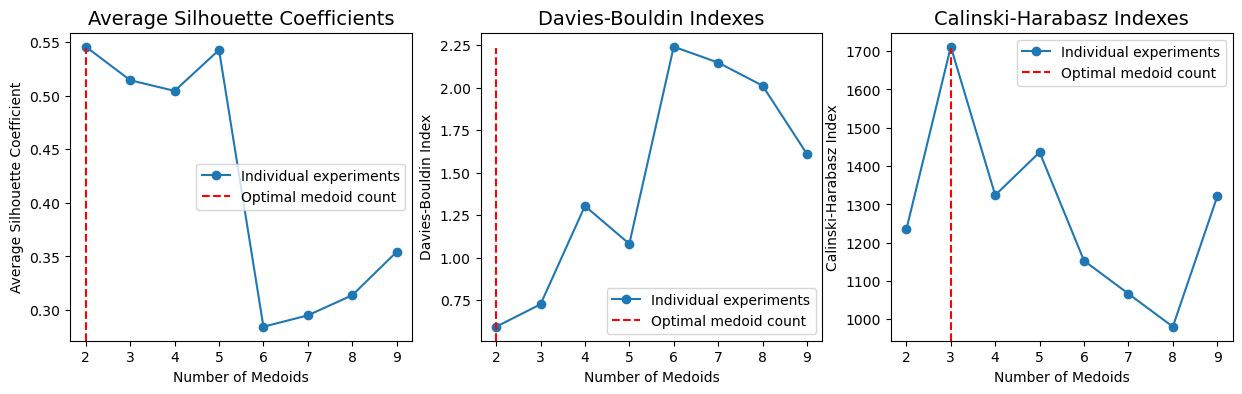

In [60]:
max_range = 10
alpha_km_s, alpha_silhouette_avg_all, alpha_davies_bouldin_all, alpha_calinski_harabasz_all = (
    get_k_medoid_clustering(alpha_dist_matrice, max_range=max_range)
)
alpha_n_medoids_best = plot_optimal_num_medoid_selection(
    alpha_silhouette_avg_all, alpha_davies_bouldin_all, alpha_calinski_harabasz_all, max_range=max_range
)
alpha_km = alpha_km_s[alpha_n_medoids_best - 2]
alpha_cluster_labels = alpha_km.labels_
alpha_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(alpha_cluster_labels, alpha_domain_types)
alpha_kmedoid_domain_subtypes = [alpha_cluster_id_2_domain_subtype[l] for l in alpha_cluster_labels]

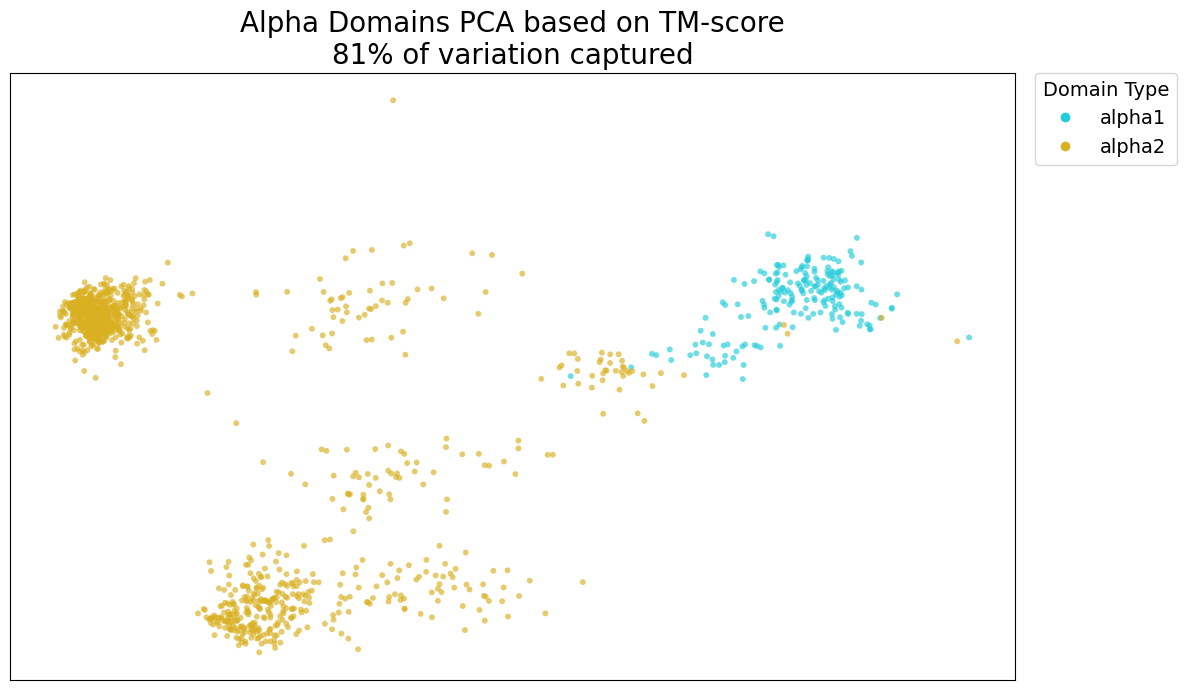

In [61]:
alpha_pairwise_closest_domains_after_clustering = get_pairwise_closest_domains(alpha_kmedoid_domain_subtypes, alpha_dist_matrice)
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha_pca_coord_dom,
    alpha_kmedoid_domain_subtypes,
    sorted(alpha_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Alpha Domains PCA based on TM-score\n{sum(alpha_explained_variance)*100:.0f}% of variation captured",
    # markings=[(module_idx, alpha_domains[module_idx]) for module_idx in alpha_pairwise_closest_domains_after_clustering[("alpha2", "alpha1")][:15]],
)
plt.show()

### HDBSCAN Clustering

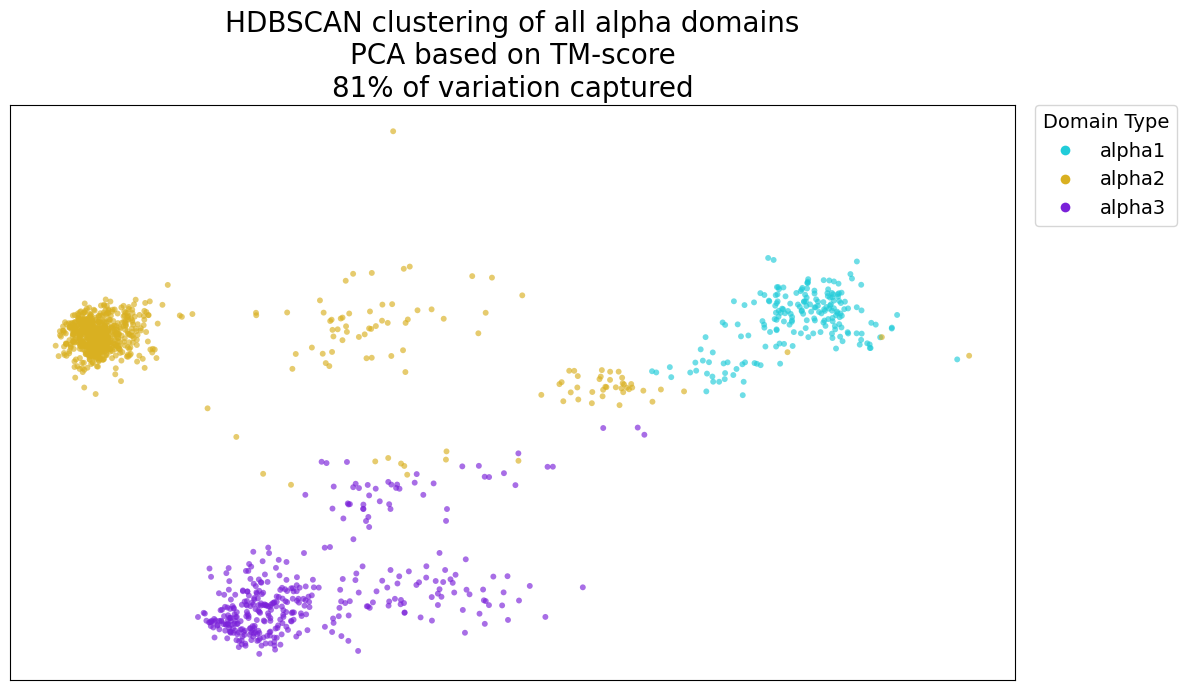

In [22]:
alpha_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=50
)  # , min_cluster_size=10)
alpha_hdbscan_clusterer.fit(alpha_dist_matrice)

fill_noise_with_closest_label(
    alpha_hdbscan_clusterer.labels_, alpha_dist_matrice, n_neighbs=31
)

alpha_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    alpha_hdbscan_clusterer.labels_, alpha_domain_types
)
alpha_hdbscan_domain_subtypes = [alpha_hdbscan_cluster_id_2_domain_subtype[l] for l in alpha_hdbscan_clusterer.labels_]
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha_pca_coord_dom,
    [{alpha_hdbscan_cluster_id_2_domain_subtype[l]} for l in alpha_hdbscan_clusterer.labels_],
    sorted(alpha_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all alpha domains\nPCA based on TM-score\n{sum(alpha_explained_variance)*100:.0f}% of variation captured",
    # markings=[(i, alpha_domains[i]) for (i,module_idx) in enumerate(alpha_idxs) if alpha_sequences[i] == "marts_E01485"],
)
plt.show()

#### Pick HDBSCAN for Alpha Domain Subtypes

In [23]:
alpha_domain_subtypes = alpha_hdbscan_domain_subtypes

### Alpha1 Domain Subsubtype Analysis

In [24]:
alpha1_idxs = [i for i, label in enumerate(alpha_domain_subtypes) if label == "alpha1"]
alpha1_dist_matrice = alpha_dist_matrice[alpha1_idxs, :][:, alpha1_idxs]
alpha1_domains = [alpha_domains[i] for i in alpha1_idxs]
alpha1_domain_types = [alpha_domain_subtypes[i] for i in alpha1_idxs]
alpha1_reaction_types = [alpha_reaction_types[i] for i in alpha1_idxs]
alpha1_sequences = [alpha_sequences[i] for i in alpha1_idxs]
alpha1_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(alpha1_sequences)]
alpha1_reaction_types_all = alpha1_martsDB.reaction_type.unique()

#### PCA Analysis

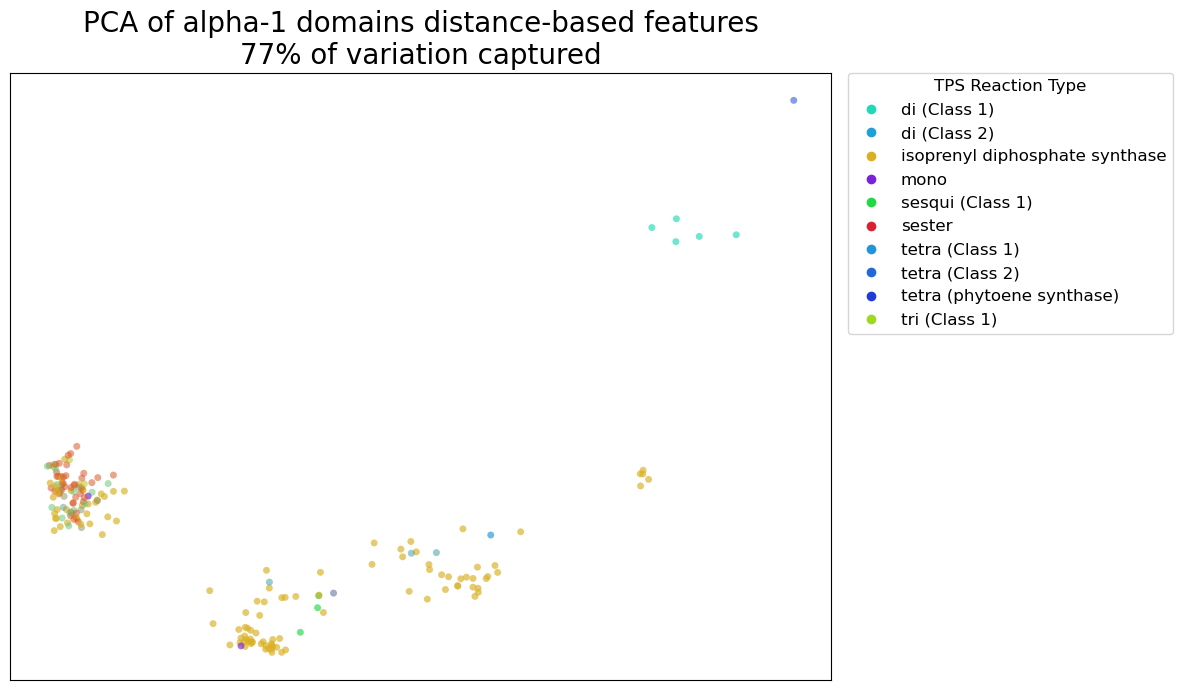

In [25]:
alpha1_pca_coord_dom, alpha1_explained_variance = get_pca_analysis(
    alpha1_dist_matrice,
    alpha1_reaction_types,
    alpha1_reaction_types_all,
    title="PCA of alpha-1 domains distance-based features",
    legend_title="TPS Reaction Type",
    marker_size=25,
    # markings=[(module_idx, alpha1_domains[module_idx]) for module_idx, rxn_type in enumerate(alpha1_reaction_types) if "di (Class 1)" in rxn_type][:30],
)


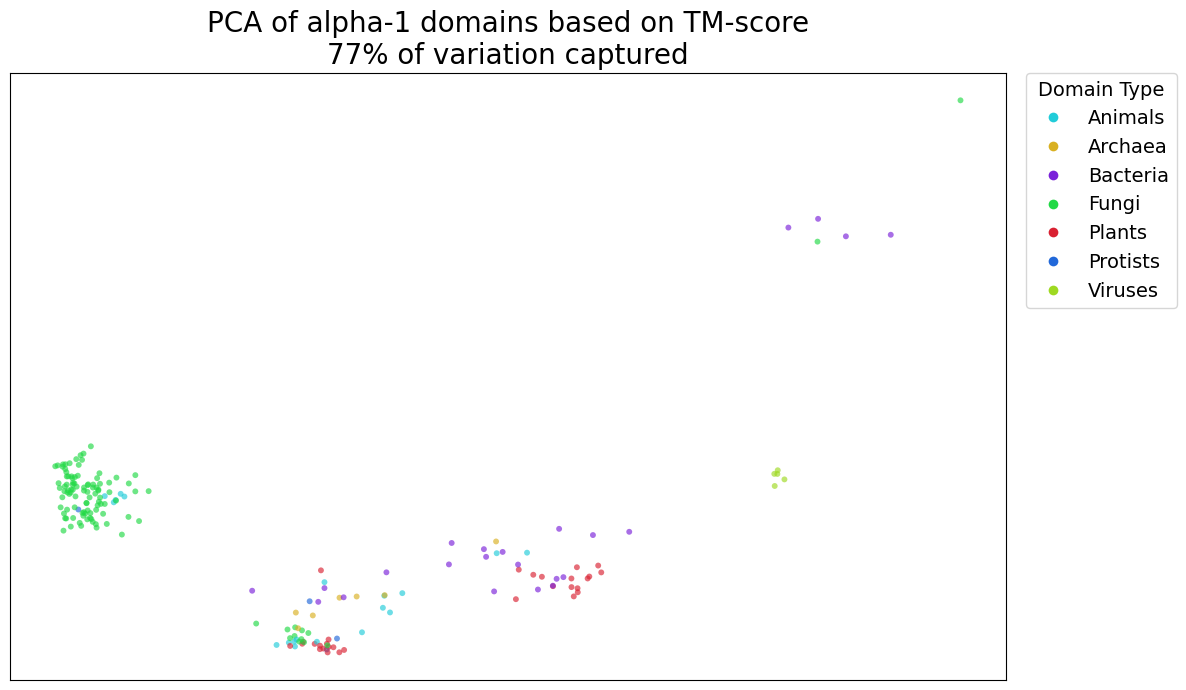

In [26]:
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha1_pca_coord_dom,
    [seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha1_sequences],
    list(set([seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha1_sequences])),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA of alpha-1 domains based on TM-score\n{sum(alpha1_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

#### K-Medoid Clustering

  0%|          | 0/8 [00:00<?, ?it/s]

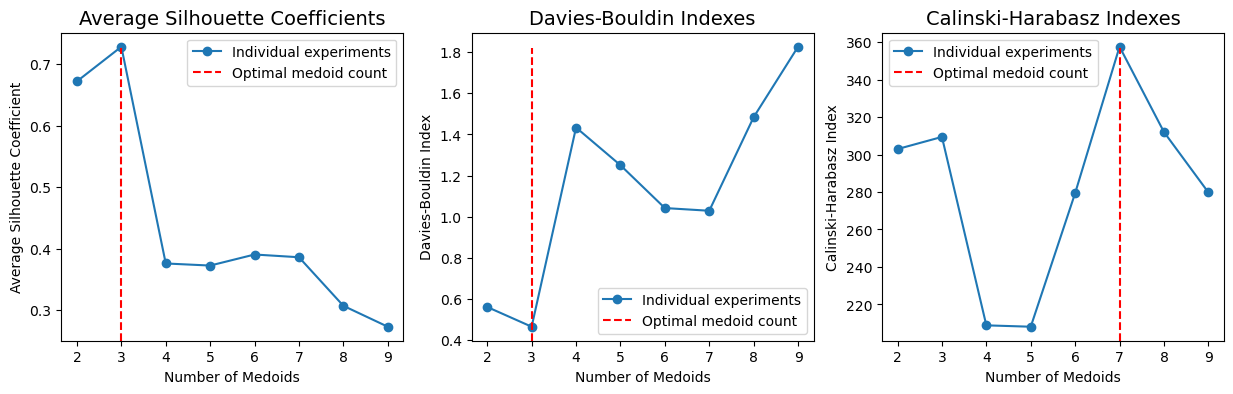

In [88]:
max_range = 10
alpha1_km_s, alpha1_silhouette_avg_all, alpha1_davies_bouldin_all, alpha1_calinski_harabasz_all = (
    get_k_medoid_clustering(alpha1_dist_matrice, max_range=max_range)
)
alpha1_n_medoids_best = plot_optimal_num_medoid_selection(
    alpha1_silhouette_avg_all, alpha1_davies_bouldin_all, alpha1_calinski_harabasz_all, max_range=max_range
)
alpha1_km = alpha1_km_s[alpha1_n_medoids_best - 2]
alpha1_cluster_labels = alpha1_km.labels_
alpha1_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(alpha1_cluster_labels, alpha1_domain_types, level=2)
alpha1_kmedoid_domain_subtypes = [alpha1_cluster_id_2_domain_subtype[l] for l in alpha1_cluster_labels]

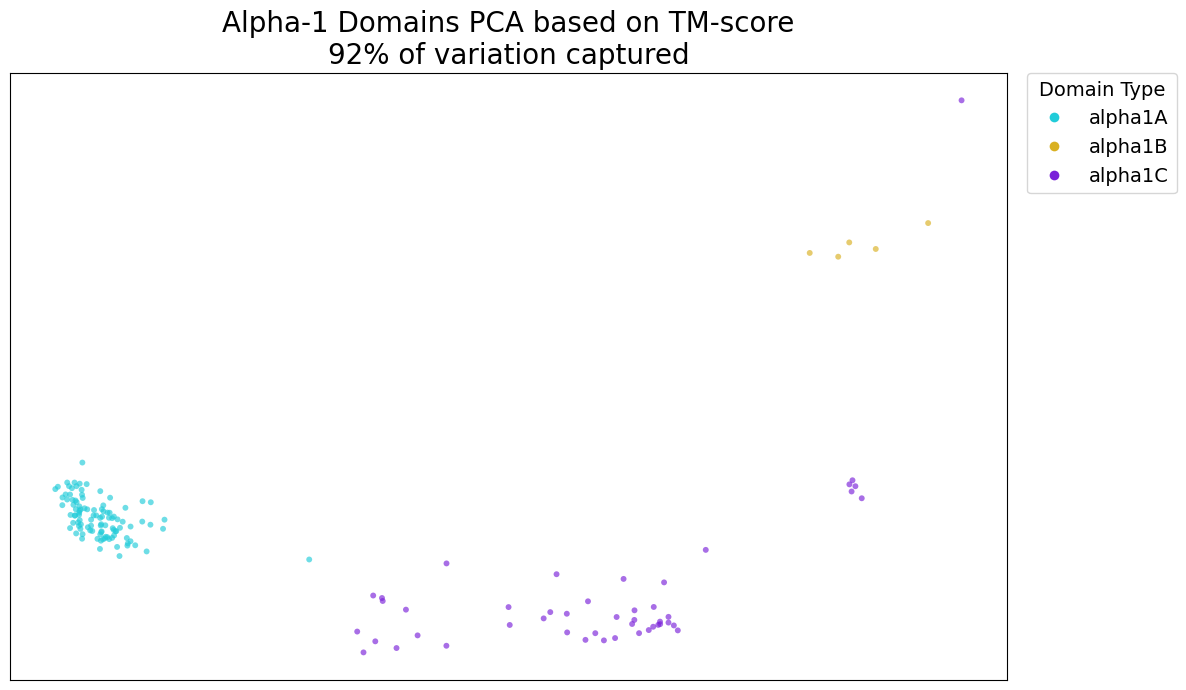

In [89]:
alpha1_pairwise_closest_domains_after_clustering = get_pairwise_closest_domains(alpha1_kmedoid_domain_subtypes, alpha1_dist_matrice)
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha1_pca_coord_dom,
    alpha1_kmedoid_domain_subtypes,
    sorted(alpha1_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Alpha-1 Domains PCA based on TM-score\n{sum(alpha1_explained_variance)*100:.0f}% of variation captured",
    # markings=[(module_idx, alpha1_domains[module_idx]) for module_idx in alpha1_pairwise_closest_domains_after_clustering[("alpha2", "alpha1")][:15]],
)
plt.show()

#### HDBSCAN Clustering

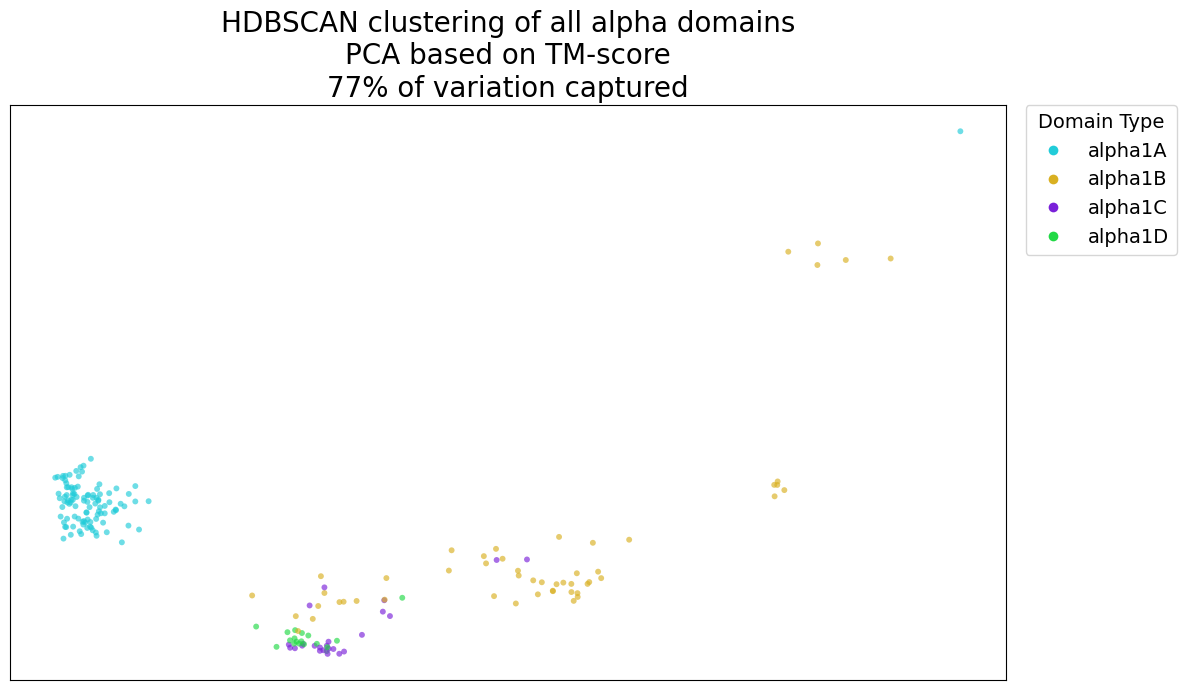

In [29]:
alpha1_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=5
)  # , min_cluster_size=10)
alpha1_hdbscan_clusterer.fit(alpha1_dist_matrice)

fill_noise_with_closest_label(
    alpha1_hdbscan_clusterer.labels_, alpha1_dist_matrice, n_neighbs=11
)

alpha1_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    alpha1_hdbscan_clusterer.labels_, alpha1_domain_types, level=2
)
alpha1_hdbscan_domain_subtypes = [alpha1_hdbscan_cluster_id_2_domain_subtype[l] for l in alpha1_hdbscan_clusterer.labels_]

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha1_pca_coord_dom,
    [{alpha1_hdbscan_cluster_id_2_domain_subtype[l]} for l in alpha1_hdbscan_clusterer.labels_],
    sorted(alpha1_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all alpha domains\nPCA based on TM-score\n{sum(alpha1_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

#### Pick HDBSCAN for Alpha-1 Domain Subsubtypes

In [105]:
alpha1_domain_subtypes = alpha1_hdbscan_domain_subtypes

### Alpha2 Domain Subsubtype Analysis

In [106]:
alpha2_idxs = [i for i, label in enumerate(alpha_domain_subtypes) if label == "alpha2"]
alpha2_dist_matrice = alpha_dist_matrice[alpha2_idxs, :][:, alpha2_idxs]
alpha2_domains = [alpha_domains[i] for i in alpha2_idxs]
alpha2_domain_types = [alpha_domain_subtypes[i] for i in alpha2_idxs]
alpha2_reaction_types = [alpha_reaction_types[i] for i in alpha2_idxs]
alpha2_sequences = [alpha_sequences[i] for i in alpha2_idxs]
alpha2_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(alpha2_sequences)]
alpha2_reaction_types_all = alpha2_martsDB.reaction_type.unique()
alpha2_dist_matrice_reduced = reduce_dimensionality_with_pca(alpha2_dist_matrice, n_components=10)

#### PCA Analysis

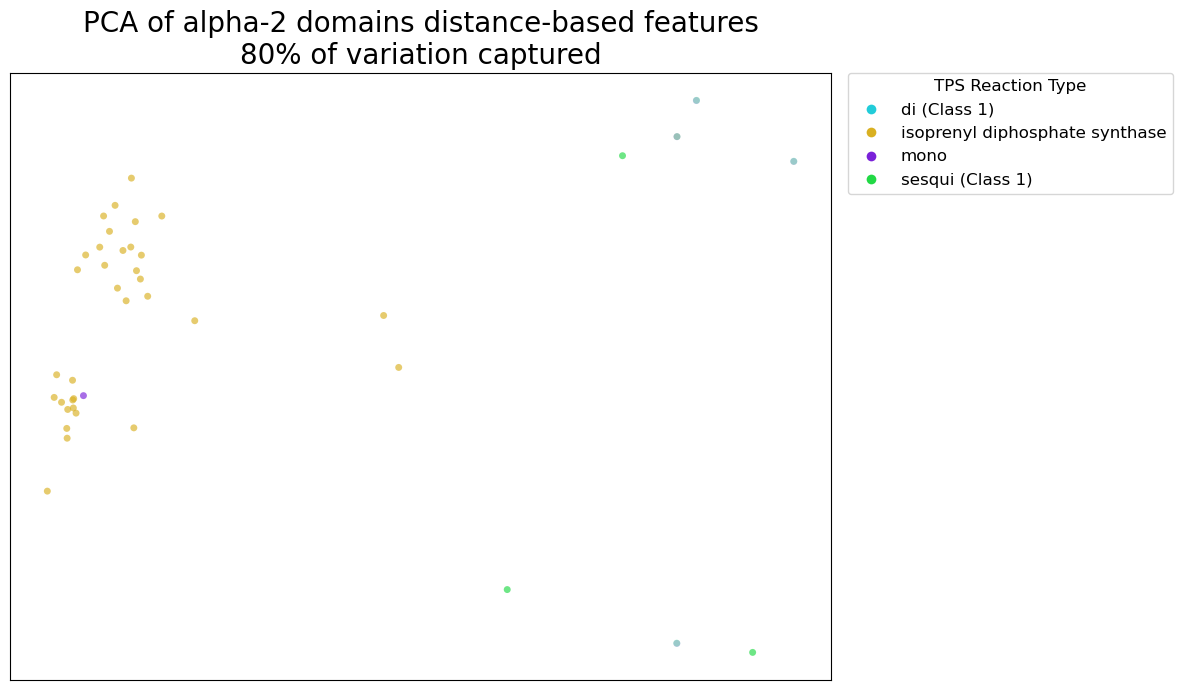

In [107]:
alpha2_pca_coord_dom, alpha2_explained_variance = get_pca_analysis(
    alpha2_dist_matrice,
    alpha2_reaction_types,
    alpha2_reaction_types_all,
    title="PCA of alpha-2 domains distance-based features",
    legend_title="TPS Reaction Type",
    marker_size=25,
)


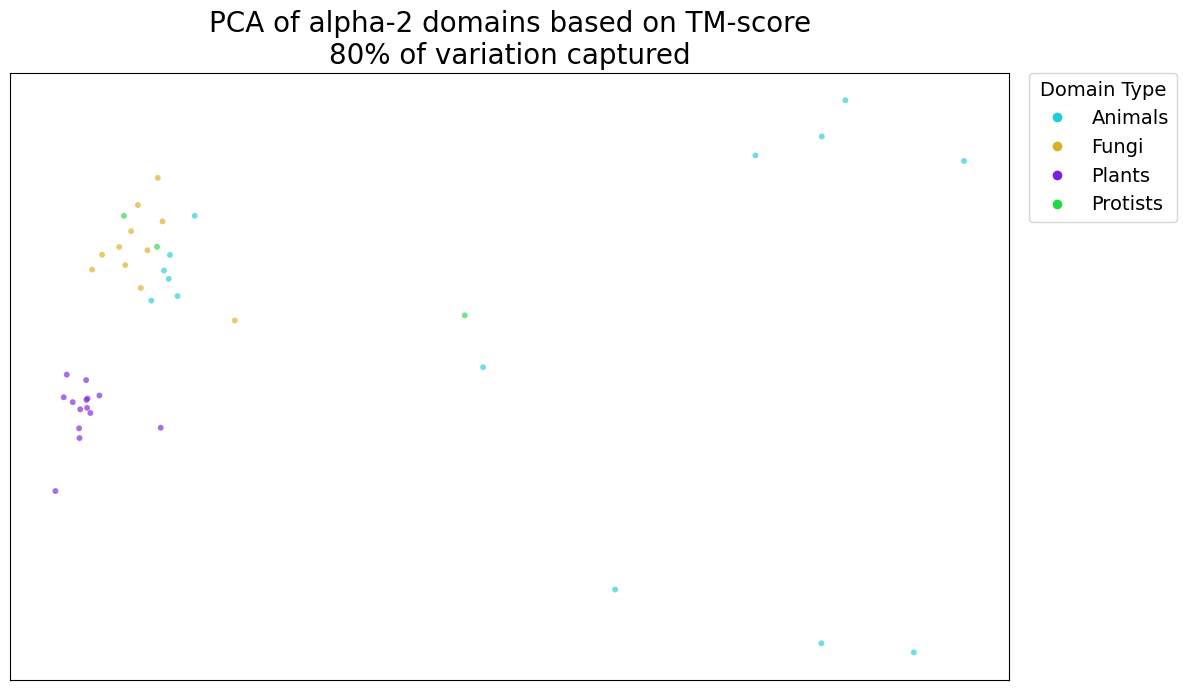

In [108]:
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha2_pca_coord_dom,
    [seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha2_sequences],
    list(set([seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha2_sequences])),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA of alpha-2 domains based on TM-score\n{sum(alpha2_explained_variance)*100:.0f}% of variation captured",
    # markings=[(idx, alpha2_domains[idx]) for idx, kingdom in enumerate([seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha2_sequences]) if kingdom=="Animals"],
)
plt.show()

#### K-Medoid Clustering

  0%|          | 0/5 [00:00<?, ?it/s]

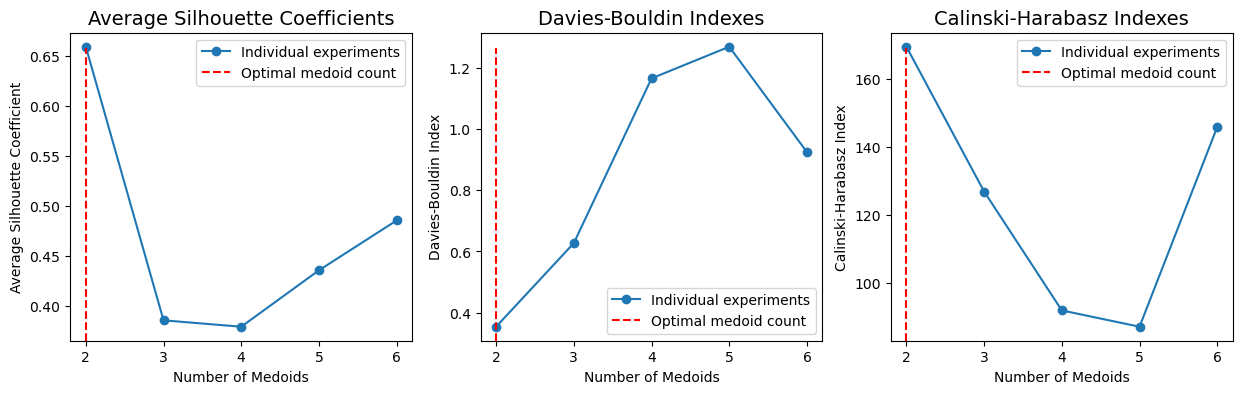

In [109]:
max_range = 7
alpha2_km_s, alpha2_silhouette_avg_all, alpha2_davies_bouldin_all, alpha2_calinski_harabasz_all = (
    get_k_medoid_clustering(alpha2_dist_matrice_reduced, max_range=max_range)
)
alpha2_n_medoids_best = plot_optimal_num_medoid_selection(
    alpha2_silhouette_avg_all, alpha2_davies_bouldin_all, alpha2_calinski_harabasz_all, max_range=max_range
)
alpha2_km = alpha2_km_s[alpha2_n_medoids_best -2]
alpha2_cluster_labels = alpha2_km.labels_
alpha2_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(alpha2_cluster_labels, alpha2_domain_types, level=2)
alpha2_kmedoid_domain_subtypes = [alpha2_cluster_id_2_domain_subtype[l] for l in alpha2_cluster_labels]

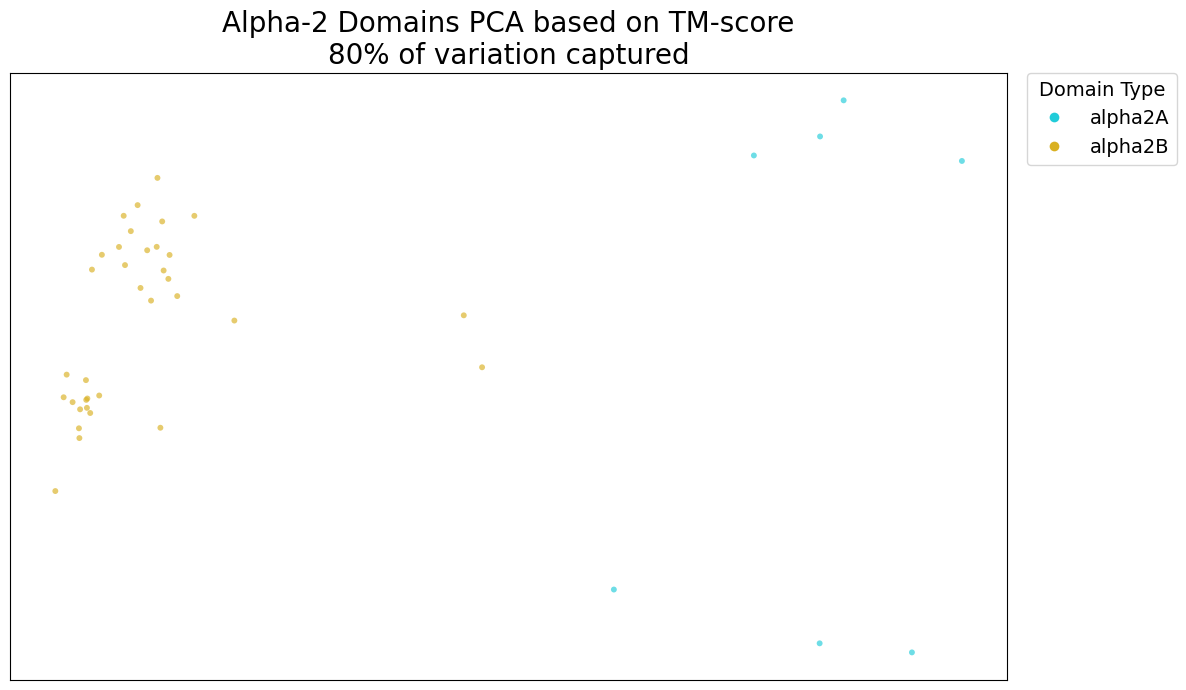

In [110]:
alpha2_pairwise_closest_domains_after_clustering = get_pairwise_closest_domains(alpha2_kmedoid_domain_subtypes, alpha2_dist_matrice_reduced)
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha2_pca_coord_dom,
    alpha2_kmedoid_domain_subtypes,
    sorted(alpha2_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Alpha-2 Domains PCA based on TM-score\n{sum(alpha2_explained_variance)*100:.0f}% of variation captured",
    # markings=[(module_idx, alpha2_domains[module_idx]) for module_idx in alpha2_pairwise_closest_domains_after_clustering[("alpha2", "alpha1")][:15]],
)
plt.show()

#### HDBSCAN Clustering

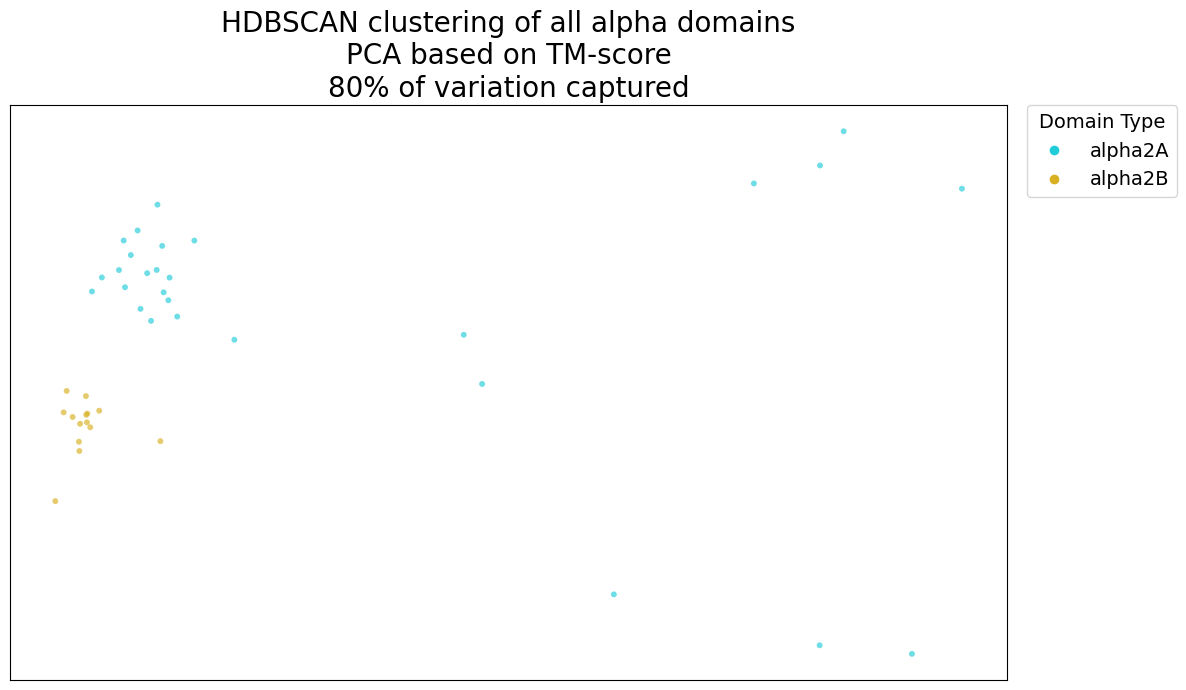

In [117]:
alpha2_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=4
)  # , min_cluster_size=10)
alpha2_hdbscan_clusterer.fit(alpha2_dist_matrice_reduced)

fill_noise_with_closest_label(
    alpha2_hdbscan_clusterer.labels_, alpha2_dist_matrice_reduced, n_neighbs=3
)

alpha2_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    alpha2_hdbscan_clusterer.labels_, alpha2_domain_types, level=2
)
alpha2_hdbscan_domain_subtypes = [alpha2_hdbscan_cluster_id_2_domain_subtype[l] for l in alpha2_hdbscan_clusterer.labels_]

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha2_pca_coord_dom,
    [{alpha2_hdbscan_cluster_id_2_domain_subtype[l]} for l in alpha2_hdbscan_clusterer.labels_],
    sorted(alpha2_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all alpha domains\nPCA based on TM-score\n{sum(alpha2_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

#### Pick HDBSCAN for Alpha-2 Domain Subsubtypes

In [118]:
alpha2_domain_subtypes = alpha2_hdbscan_domain_subtypes

### Alpha3 Domain Subsubtype Analysis

In [119]:
alpha3_idxs = [i for i, label in enumerate(alpha_domain_subtypes) if label == "alpha3"]
alpha3_dist_matrice = alpha_dist_matrice[alpha3_idxs, :][:, alpha3_idxs]
alpha3_domains = [alpha_domains[i] for i in alpha3_idxs]
alpha3_domain_types = [alpha_domain_subtypes[i] for i in alpha3_idxs]
alpha3_reaction_types = [alpha_reaction_types[i] for i in alpha3_idxs]
alpha3_sequences = [alpha_sequences[i] for i in alpha3_idxs]
alpha3_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(alpha3_sequences)]
alpha3_reaction_types_all = alpha3_martsDB.reaction_type.unique()

#### PCA Analysis

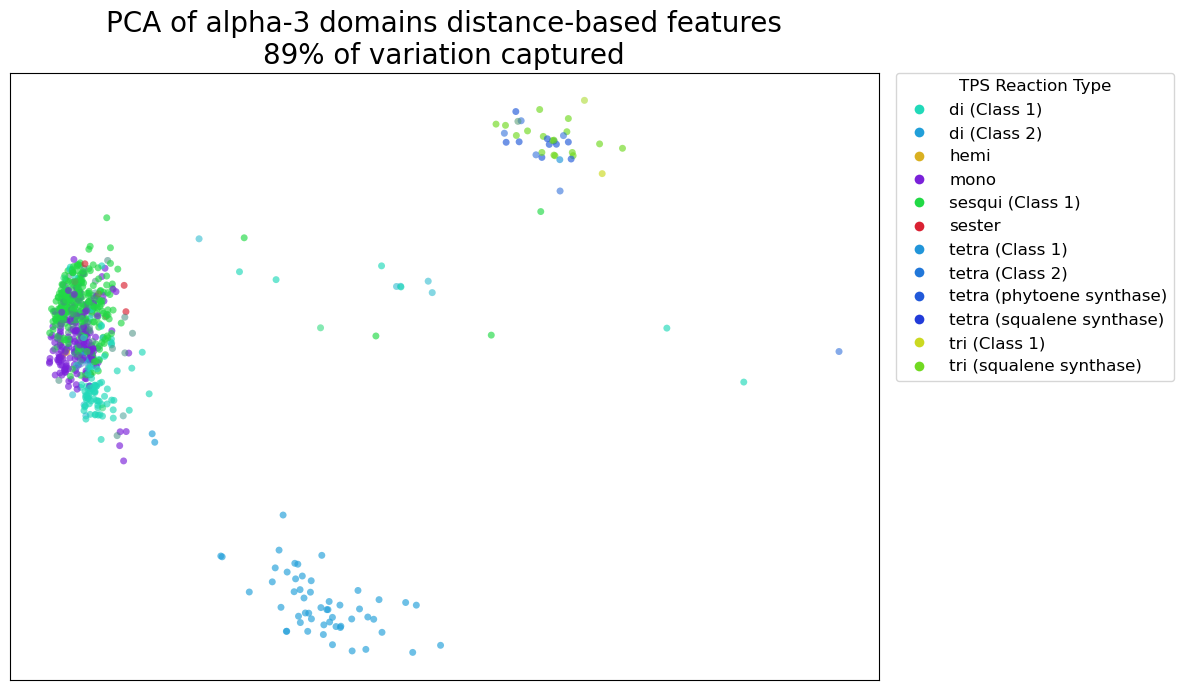

In [120]:
alpha3_pca_coord_dom, alpha3_explained_variance = get_pca_analysis(
    alpha3_dist_matrice,
    alpha3_reaction_types,
    alpha3_reaction_types_all,
    title="PCA of alpha-3 domains distance-based features",
    legend_title="TPS Reaction Type",
    marker_size=25,
)


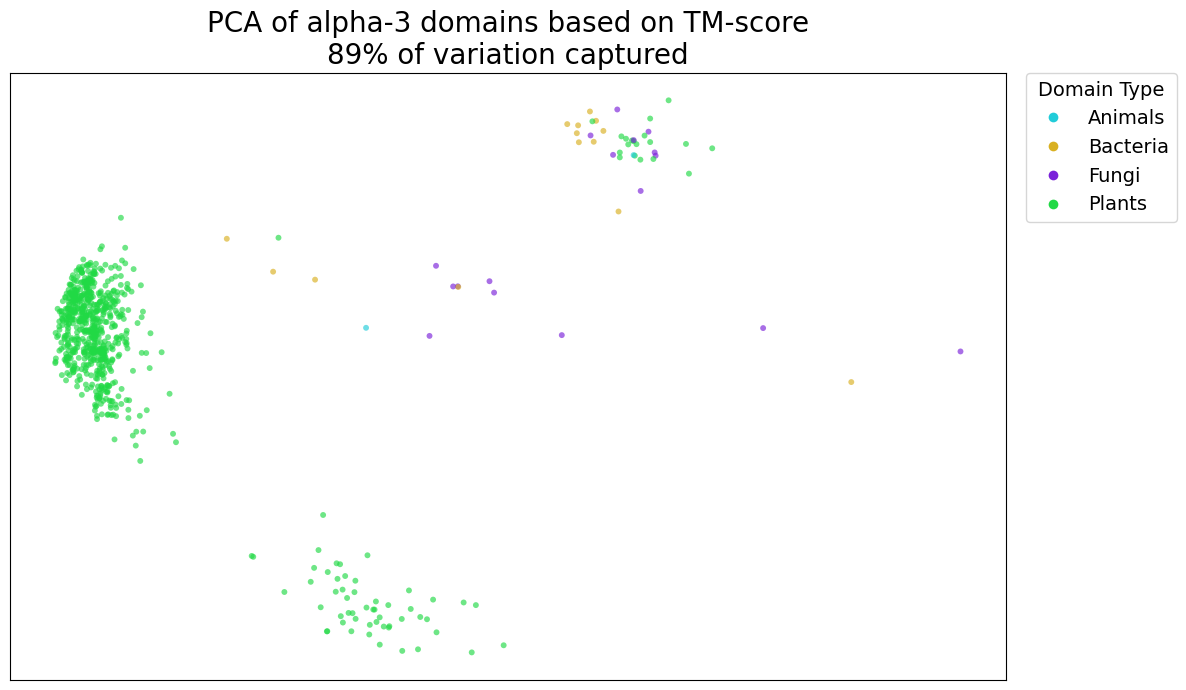

In [121]:
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha3_pca_coord_dom,
    [seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha3_sequences],
    list(set([seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha3_sequences])),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA of alpha-3 domains based on TM-score\n{sum(alpha3_explained_variance)*100:.0f}% of variation captured",
    # markings=[(idx, alpha3_domains[idx]) for idx, kingdom in enumerate([seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha3_sequences]) if kingdom=="Animals"],
)
plt.show()

#### K-Medoid Clustering

  0%|          | 0/13 [00:00<?, ?it/s]

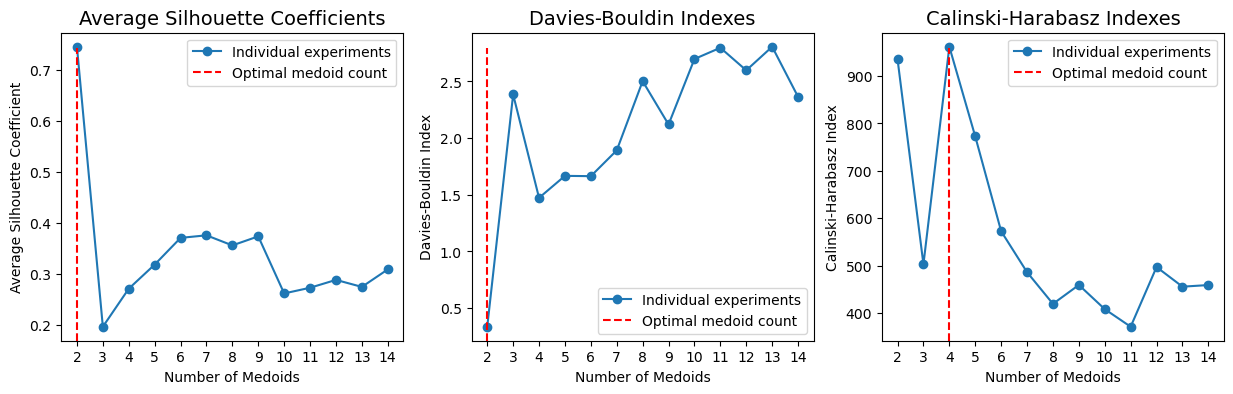

In [122]:
max_range = 15
alpha3_km_s, alpha3_silhouette_avg_all, alpha3_davies_bouldin_all, alpha3_calinski_harabasz_all = (
    get_k_medoid_clustering(alpha3_dist_matrice, max_range=max_range)
)
alpha3_n_medoids_best = plot_optimal_num_medoid_selection(
    alpha3_silhouette_avg_all, alpha3_davies_bouldin_all, alpha3_calinski_harabasz_all, max_range=max_range
)
alpha3_km = alpha3_km_s[alpha3_n_medoids_best - 2]
alpha3_cluster_labels = alpha3_km.labels_
alpha3_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(alpha3_cluster_labels, alpha3_domain_types, level=2)
alpha3_kmedoid_domain_subtypes = [alpha3_cluster_id_2_domain_subtype[l] for l in alpha3_cluster_labels]

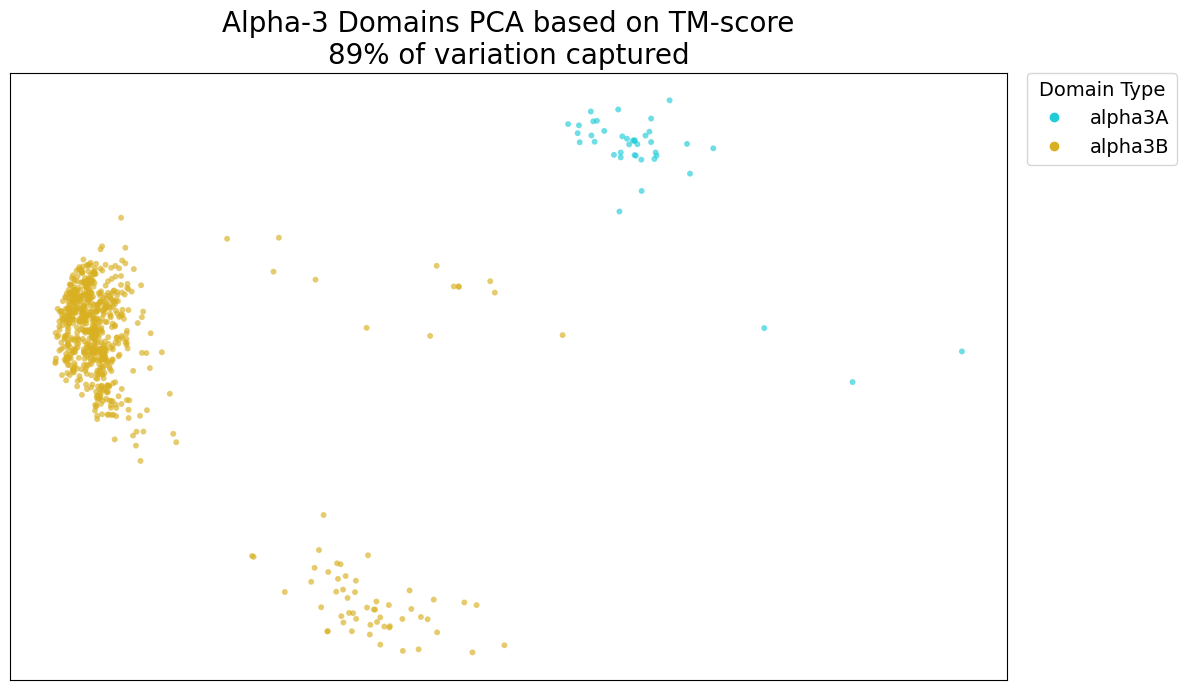

In [123]:
alpha3_pairwise_closest_domains_after_clustering = get_pairwise_closest_domains(alpha3_kmedoid_domain_subtypes, alpha3_dist_matrice)
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha3_pca_coord_dom,
    alpha3_kmedoid_domain_subtypes,
    sorted(alpha3_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Alpha-3 Domains PCA based on TM-score\n{sum(alpha3_explained_variance)*100:.0f}% of variation captured",
    # markings=[(module_idx, alpha3_domains[module_idx]) for module_idx in alpha3_pairwise_closest_domains_after_clustering[("alpha3", "alpha1")][:15]],
)
plt.show()

#### HDBSCAN Clustering

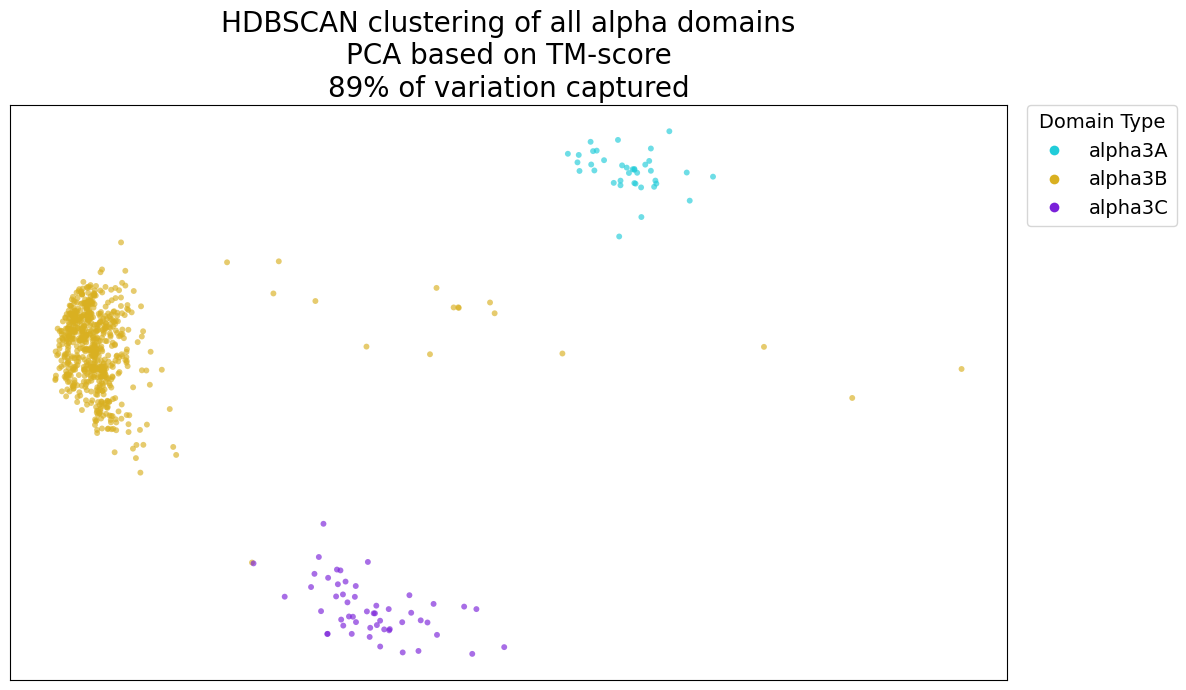

In [138]:
alpha3_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=15
)  # , min_cluster_size=10)
alpha3_hdbscan_clusterer.fit(alpha3_dist_matrice)

fill_noise_with_closest_label(
    alpha3_hdbscan_clusterer.labels_, alpha3_dist_matrice, n_neighbs=11
)

alpha3_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    alpha3_hdbscan_clusterer.labels_, alpha3_domain_types, level=2
)

alpha3_hdbscan_domain_subtypes = [alpha3_hdbscan_cluster_id_2_domain_subtype[l] for l in alpha3_hdbscan_clusterer.labels_]

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha3_pca_coord_dom,
    [{alpha3_hdbscan_cluster_id_2_domain_subtype[l]} for l in alpha3_hdbscan_clusterer.labels_],
    sorted(alpha3_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all alpha domains\nPCA based on TM-score\n{sum(alpha3_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

#### Pick HDBSCAN for Alpha-3 Domain Subsubtypes

In [139]:
alpha3_domain_subtypes = alpha3_hdbscan_domain_subtypes

### Alpha4 Domain Subsubtype Analysis

In [126]:
alpha4_idxs = [i for i, label in enumerate(alpha_domain_subtypes) if label == "alpha4"]
alpha4_dist_matrice = alpha_dist_matrice[alpha4_idxs, :][:, alpha4_idxs]
alpha4_domains = [alpha_domains[i] for i in alpha4_idxs]
alpha4_domain_types = [alpha_domain_subtypes[i] for i in alpha4_idxs]
alpha4_reaction_types = [alpha_reaction_types[i] for i in alpha4_idxs]
alpha4_sequences = [alpha_sequences[i] for i in alpha4_idxs]
alpha4_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(alpha4_sequences)]
alpha4_reaction_types_all = alpha4_martsDB.reaction_type.unique()

#### PCA Analysis

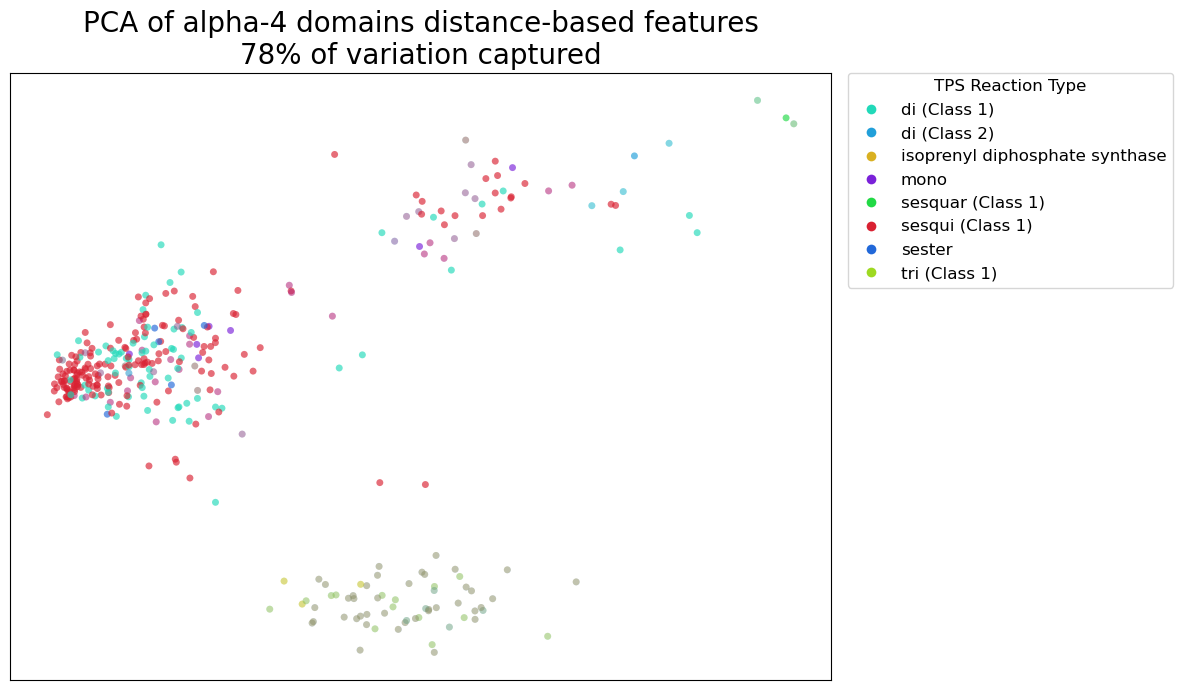

In [127]:
alpha4_pca_coord_dom, alpha4_explained_variance = get_pca_analysis(
    alpha4_dist_matrice,
    alpha4_reaction_types,
    alpha4_reaction_types_all,
    title="PCA of alpha-4 domains distance-based features",
    legend_title="TPS Reaction Type",
    marker_size=25,
)


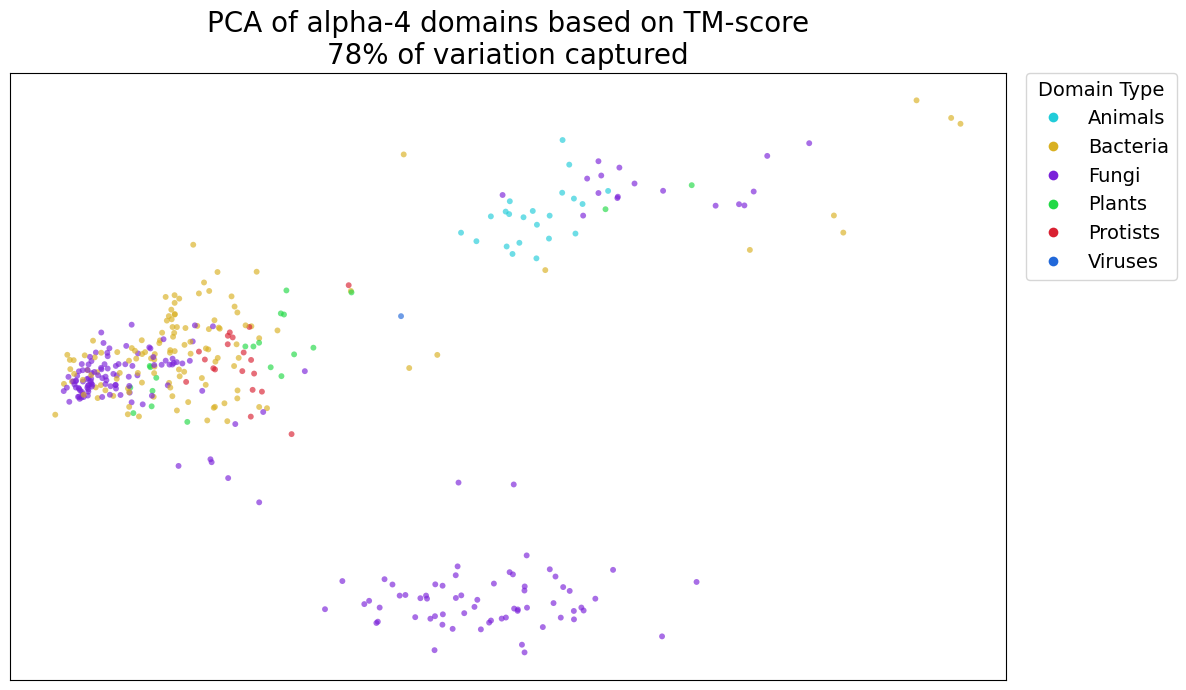

In [128]:
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha4_pca_coord_dom,
    [seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha4_sequences],
    list(set([seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha4_sequences])),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA of alpha-4 domains based on TM-score\n{sum(alpha4_explained_variance)*100:.0f}% of variation captured",
    # markings=[(idx, alpha4_domains[idx]) for idx, kingdom in enumerate([seq_to_kingdom[domain_seq_id] for domain_seq_id in alpha4_sequences]) if kingdom=="Animals"],
)
plt.show()

#### K-Medoid Clustering

  0%|          | 0/13 [00:00<?, ?it/s]

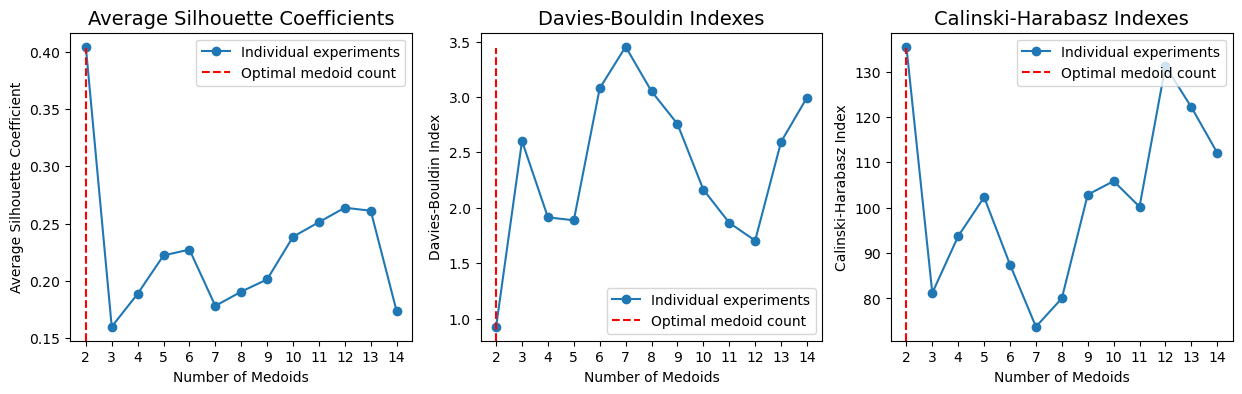

In [129]:
max_range = 15
alpha4_km_s, alpha4_silhouette_avg_all, alpha4_davies_bouldin_all, alpha4_calinski_harabasz_all = (
    get_k_medoid_clustering(alpha4_dist_matrice, max_range=max_range)
)
alpha4_n_medoids_best = plot_optimal_num_medoid_selection(
    alpha4_silhouette_avg_all, alpha4_davies_bouldin_all, alpha4_calinski_harabasz_all, max_range=max_range
)
alpha4_km = alpha4_km_s[alpha4_n_medoids_best - 2]
alpha4_cluster_labels = alpha4_km.labels_
alpha4_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(alpha4_cluster_labels, alpha4_domain_types, level=2)
alpha4_kmedoid_domain_subtypes = [alpha4_cluster_id_2_domain_subtype[l] for l in alpha4_cluster_labels]

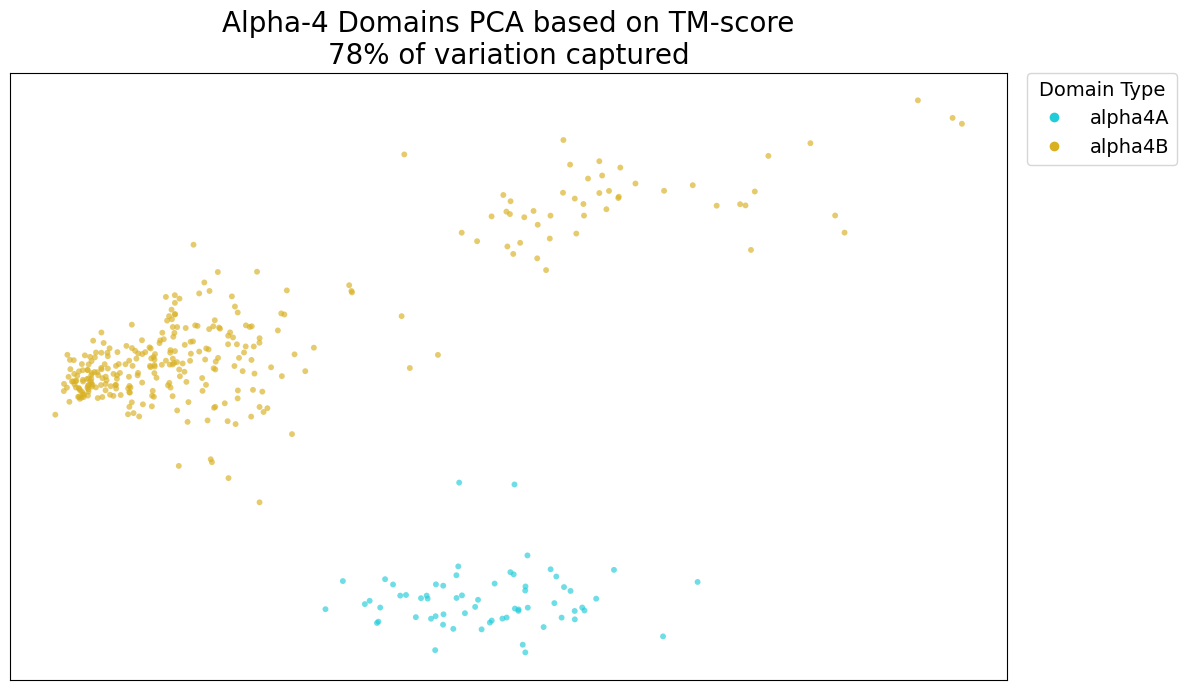

In [130]:
alpha4_pairwise_closest_domains_after_clustering = get_pairwise_closest_domains(alpha4_kmedoid_domain_subtypes, alpha4_dist_matrice)
fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha4_pca_coord_dom,
    alpha4_kmedoid_domain_subtypes,
    sorted(alpha4_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Alpha-4 Domains PCA based on TM-score\n{sum(alpha4_explained_variance)*100:.0f}% of variation captured",
    # markings=[(module_idx, alpha4_domains[module_idx]) for module_idx in alpha4_pairwise_closest_domains_after_clustering[("alpha4", "alpha1")][:15]],
)
plt.show()

#### HDBSCAN Clustering

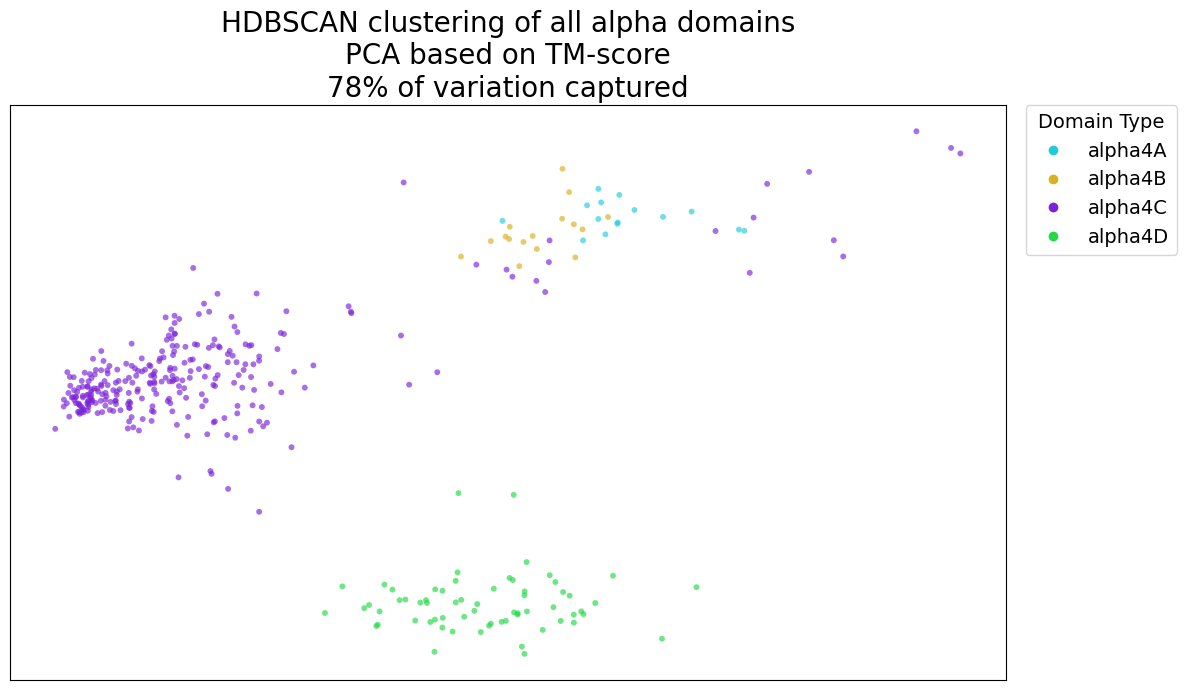

In [140]:
alpha4_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=11
)  # , min_cluster_size=10)
alpha4_hdbscan_clusterer.fit(alpha4_dist_matrice)

fill_noise_with_closest_label(
    alpha4_hdbscan_clusterer.labels_, alpha4_dist_matrice, n_neighbs=13
)

alpha4_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    alpha4_hdbscan_clusterer.labels_, alpha4_domain_types, level=2
)

alpha4_hdbscan_domain_subtypes = [alpha4_hdbscan_cluster_id_2_domain_subtype[l] for l in alpha4_hdbscan_clusterer.labels_]

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha4_pca_coord_dom,
    [{alpha4_hdbscan_cluster_id_2_domain_subtype[l]} for l in alpha4_hdbscan_clusterer.labels_],
    sorted(alpha4_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all alpha domains\nPCA based on TM-score\n{sum(alpha4_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

#### Pick HDBSCAN for Alpha-4 Domain Subsubtypes

In [142]:
alpha4_domain_subtypes = alpha4_hdbscan_domain_subtypes

## Save Domain Subtypes

In [143]:
domain_module_id_2_domain_subtype = {}
for idx, domain in enumerate(non_alpha_domains):
    if domain not in domain_module_id_2_domain_subtype:
        domain_module_id_2_domain_subtype[domain] = non_alpha_domain_types[idx]
    else:
        raise ValueError(
            f"Domain {domain} already has a subtype assigned: {domain_module_id_2_domain_subtype[domain]}. This should not happen."
        )
for idx, domain in enumerate(alpha1_domains):
    if domain not in domain_module_id_2_domain_subtype:
        domain_module_id_2_domain_subtype[domain] = alpha1_domain_subtypes[idx]
for idx, domain in enumerate(alpha2_domains):
    if domain not in domain_module_id_2_domain_subtype:
        domain_module_id_2_domain_subtype[domain] = alpha2_domain_subtypes[idx]
for idx, domain in enumerate(alpha3_domains):
    if domain not in domain_module_id_2_domain_subtype:
        domain_module_id_2_domain_subtype[domain] = alpha3_domain_subtypes[idx]
for idx, domain in enumerate(alpha4_domains):
    if domain not in domain_module_id_2_domain_subtype:
        domain_module_id_2_domain_subtype[domain] = alpha4_domain_subtypes[idx]
    else:
        raise ValueError(
            f"Domain {domain} already has a subtype assigned: {domain_module_id_2_domain_subtype[domain]}. This should not happen."
        )

In [ ]:
assert set(domain_module_id_2_domain_subtype.keys()) == set(domains)
pickle.dump(domain_module_id_2_domain_subtype, open("../data/domain_module_id_2_domain_subtype.pkl", "wb"))
set(domain_module_id_2_domain_subtype.values())

{'alpha1A',
 'alpha1B',
 'alpha1C',
 'alpha1D',
 'alpha2A',
 'alpha2B',
 'alpha3A',
 'alpha3B',
 'alpha3C',
 'alpha4A',
 'alpha4B',
 'alpha4C',
 'alpha4D',
 'beta',
 'delta',
 'epsilon',
 'gamma'}

## Plot Final Domain Types

(array([[-42.83629561,   7.17489807],
        [ 51.75301977,  17.11814994],
        [-30.92831337,   0.98096629],
        ...,
        [-36.21707746,   2.57084644],
        [-45.2098617 ,   9.02494378],
        [ 52.0564091 ,  18.45586337]]),
 array([0.67337108, 0.12691071]))

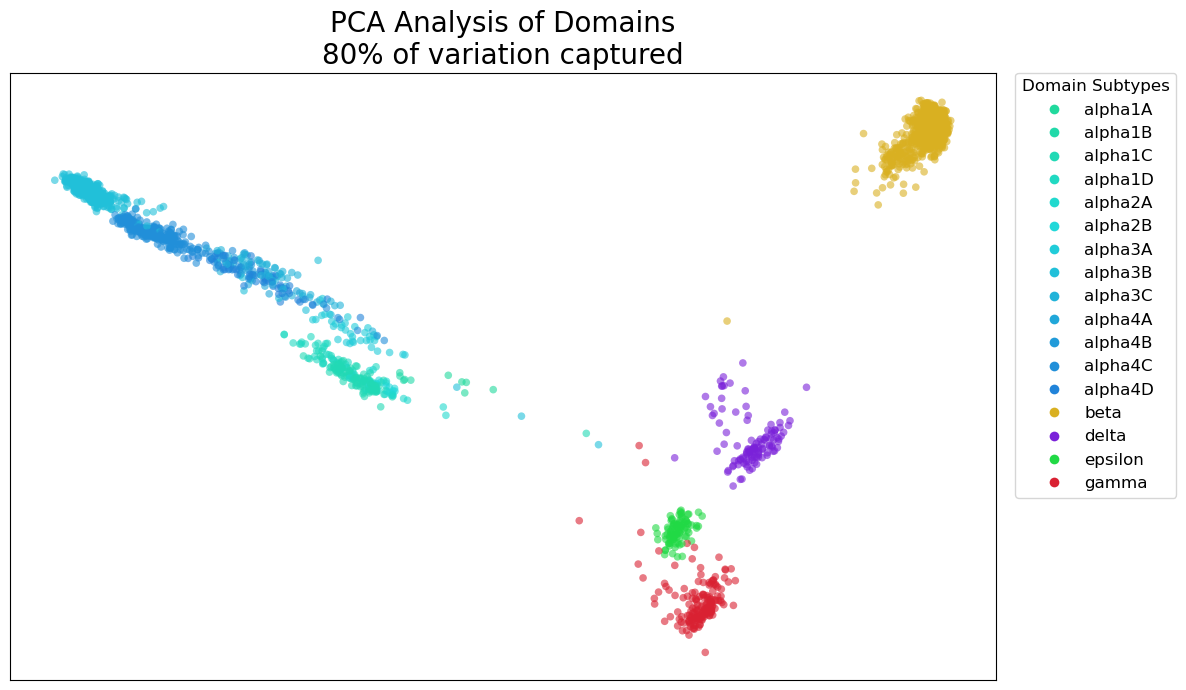

In [ ]:
domain_module_id_2_domain_subtype = pickle.load(open("../data/domain_module_id_2_domain_subtype.pkl", "rb"))
get_pca_analysis(
    domains_dist_matrice,
    [domain_module_id_2_domain_subtype[domain] for domain in domains],
    all_reaction_types=set(domain_module_id_2_domain_subtype.values()),
    title="PCA Analysis of Domains",
    legend_title="Domain Subtypes",
    group_key_fn=lambda s: "".join(itertools.takewhile(str.isalpha, s)),
    marker_size=30,
    base_alpha=0.6,
    safety=0.9
)

(array([[-2.08218364e+01,  8.38796294e+00],
        [-1.05358673e-02, -9.75302425e+00],
        [ 5.96671912e+00,  8.48703318e+00],
        ...,
        [ 6.06739199e+01,  9.34236868e+00],
        [-3.46368343e+00, -2.21124992e+01],
        [-2.43560068e+01,  1.06445416e+01]]),
 array([0.63607334, 0.17274837]))

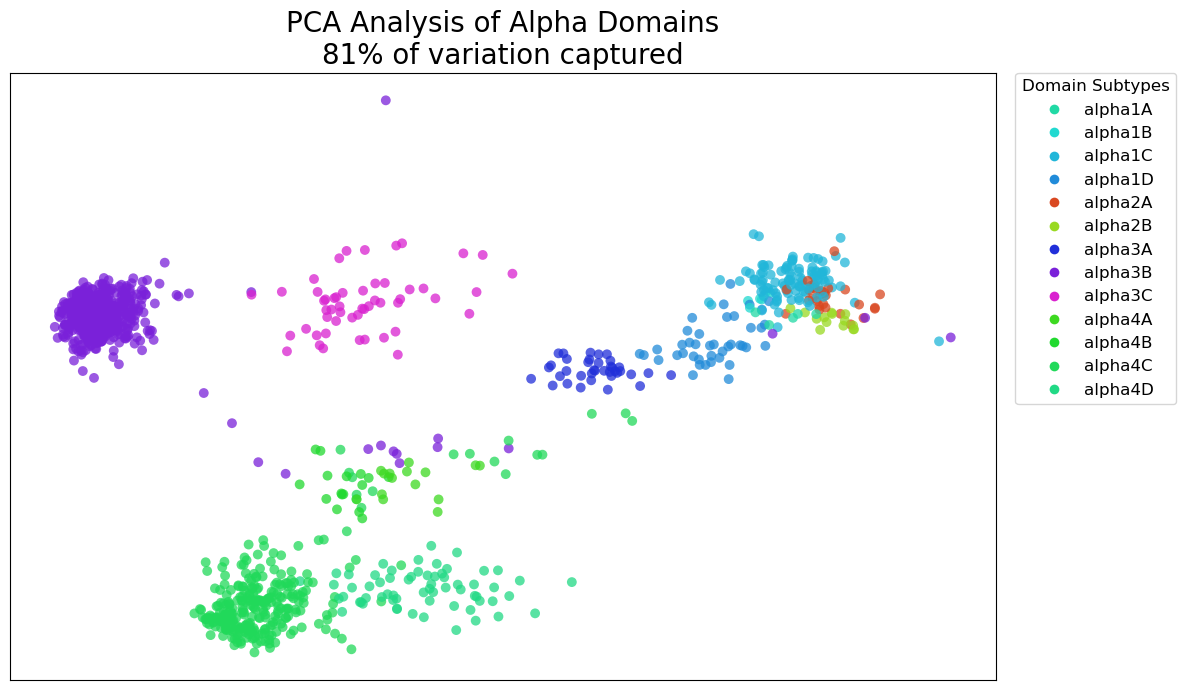

In [150]:
get_pca_analysis(
    alpha_dist_matrice,
    [domain_module_id_2_domain_subtype[domain] for domain in alpha_domains],
    all_reaction_types=set([domain_module_id_2_domain_subtype[domain] for domain in alpha_domains]),
    title="PCA Analysis of Alpha Domains",
    legend_title="Domain Subtypes",
    group_key_fn=lambda s: s[:-1],
    safety=0.8,
    marker_size=50,
    base_alpha=0.75
)

(array([[-22.32281122,   0.14449549],
        [-20.78793357,   1.2410169 ],
        [ 50.44819286,  17.76081352],
        ...,
        [-18.08123689,   1.27029706],
        [-11.74691576,  -0.92588169],
        [-23.45696985,  -1.33396245]]),
 array([0.72296774, 0.12261004]))

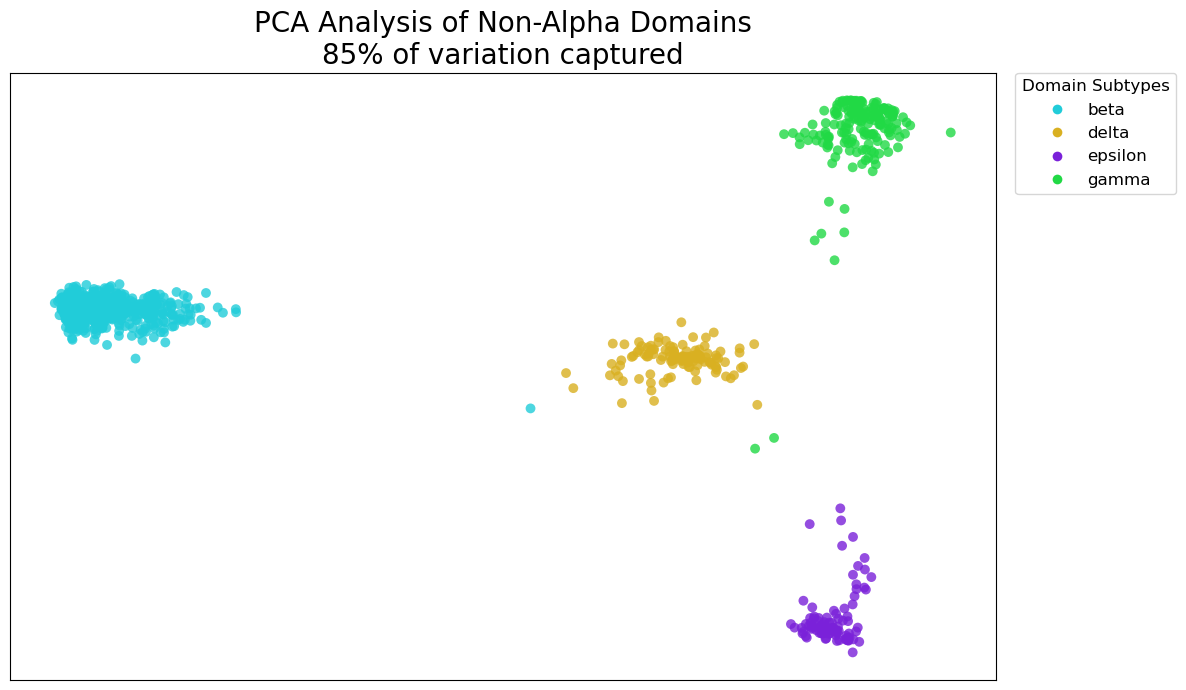

In [151]:
get_pca_analysis(
    non_alpha_dist_matrice,
    [domain_module_id_2_domain_subtype[domain] for domain in non_alpha_domains],
    all_reaction_types=set([domain_module_id_2_domain_subtype[domain] for domain in non_alpha_domains]),
    title="PCA Analysis of Non-Alpha Domains",
    legend_title="Domain Subtypes",
    group_key_fn=lambda s: s[:-1],
    marker_size=50,
    safety=0.7,
    base_alpha=0.8
)

# Analyse Domain Subtypes

In [4]:
domain_module_id_2_domain_subtype = pickle.load(open("../data/domain_module_id_2_domain_subtype.pkl", "rb"))
domain_module_id_2_seq_id = {
    domain: "_".join(domain.split("_")[:2]) for domain in domain_module_id_2_domain_subtype.keys()
}
seq_id_2_domain_subtypes = defaultdict(list)
for domain, domain_subtype in domain_module_id_2_domain_subtype.items():
    seq_id = domain_module_id_2_seq_id[domain]
    seq_id_2_domain_subtypes[seq_id].append(domain_subtype)
seq_id_2_domain_subtypes = {seq_id: sorted(subtypes) for seq_id, subtypes in seq_id_2_domain_subtypes.items()}
domain_subtype_2_seq_ids = defaultdict(list)
for seq_id, domain_subtypes in seq_id_2_domain_subtypes.items():
    for domain_subtype in domain_subtypes:
        domain_subtype_2_seq_ids[domain_subtype].append(seq_id)
domain_subtype_2_seq_ids = {domain_subtype: sorted(seq_ids) for domain_subtype, seq_ids in domain_subtype_2_seq_ids.items()}

In [9]:
domain_configs_2_seq_ids = defaultdict(list)
for seq_id, domain_subtypes in seq_id_2_domain_subtypes.items():
    domain_config = "_".join(domain_subtypes)
    domain_configs_2_seq_ids[domain_config].append(seq_id)
domain_configs_2_seq_ids = {domain_config: sorted(seq_ids) for domain_config, seq_ids in domain_configs_2_seq_ids.items()}
domain_configs_2_num_seq_ids = {domain_config: len(seq_ids) for domain_config, seq_ids in domain_configs_2_seq_ids.items()}

In [147]:
domain_configs_2_seq_ids["alpha1B_zeta"]

['marts_E00254', 'marts_E00489']

In [ ]:
seq_id_2_domains = pickle.load(open("../data/detected_domains/martsDB_detected_domains/martsDB_detected_domains.pkl", "rb"))
seq_id_2_domains = {
    seq_id: sorted(domains, key=lambda dom: sum([res_id for res_id in dom.residues_mapping]))
    for seq_id, domains in seq_id_2_domains.items()
}


In [111]:
config = "alpha2B_alpha3C"
set(["_".join([domain_module_id_2_domain_subtype[dom.module_id] for dom in seq_id_2_domains[seq_id]]) for seq_id in domain_configs_2_seq_ids[config]])

{'alpha2B_alpha3C'}

In [109]:
sorted(domain_configs_2_num_seq_ids.items(), key=lambda x: x[0], reverse=False)

[('alpha1A', 17),
 ('alpha1B', 18),
 ('alpha1B_zeta', 2),
 ('alpha2A', 9),
 ('alpha2B', 2),
 ('alpha2B_alpha3C', 62),
 ('alpha2C', 1),
 ('alpha2C_delta2_gamma', 9),
 ('alpha2D', 4),
 ('alpha2D_beta', 555),
 ('alpha2D_beta_gamma', 153),
 ('alpha2D_delta2_gamma', 1),
 ('alpha2E', 17),
 ('alpha2F', 261),
 ('alpha2F_alpha2F', 2),
 ('alpha2G', 20),
 ('alpha3A', 7),
 ('alpha3B', 46),
 ('alpha3C', 82),
 ('alpha3C_delta2_gamma', 1),
 ('delta1_epsilon', 96),
 ('delta2', 1),
 ('delta2_gamma', 8)]

## Kingdoms

In [11]:
assert set(martsDB.Kingdom.unique()) == set(['Plants', 'Fungi', 'Bacteria', 'Animals', 'Protists', 'Archaea','Viruses'])
kingdom_2_color = dict(zip(['Plants', 'Fungi', 'Bacteria', 'Animals', 'Protists', 'Archaea','Viruses'], 
                           ['#20E478', '#F1A978', '#FFD966', '#FF4343', '#5B9BD5', '#EA8FBF', '#2F5597']))


kingdom_2_domain_configs: dict[str, list[tuple[tuple[str], int, float]]] = {}
domain_config_2_kingdoms: dict[tuple[str], list[tuple[str, int, float]]] = {}
for kingdom in set(martsDB.Kingdom.unique()):
    seq_ids = martsDB[martsDB.Kingdom == kingdom].Enzyme_marts_ID.unique()
    domain_configs = [tuple(seq_id_2_domain_subtypes[seq_id]) for seq_id in seq_ids]
    domain_config_ctr = Counter(domain_configs)
    kingdom_2_domain_configs[kingdom] = [(domain_config, count, count / len(domain_configs)) for domain_config, count in domain_config_ctr.items()]
    
for domain_config in set([config for configs in kingdom_2_domain_configs.values() for config, _, _ in configs]):
    kingdoms_with_config = [(kingdom, count) for kingdom, configs in kingdom_2_domain_configs.items() for config, count, _ in configs if config == domain_config]
    kingdoms_with_config = sorted(kingdoms_with_config, key=lambda x: x[1], reverse=True)
    kingdoms_with_config = [(kingdom, count, count / sum(count for _, count in kingdoms_with_config)) for kingdom, count in kingdoms_with_config]
    domain_config_2_kingdoms[domain_config] = kingdoms_with_config
import pprint
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(domain_config_2_kingdoms)

{   ('alpha1A',): [   ('Plants', 10, 0.5882352941176471),
                      ('Fungi', 6, 0.35294117647058826),
                      ('Animals', 1, 0.058823529411764705)],
    ('alpha1B',): [('Plants', 9, 0.5), ('Bacteria', 9, 0.5)],
    ('alpha1B', 'zeta'): [('Fungi', 2, 1.0)],
    ('alpha2A',): [   ('Animals', 6, 0.6666666666666666),
                      ('Bacteria', 3, 0.3333333333333333)],
    ('alpha2B',): [('Fungi', 2, 1.0)],
    ('alpha2B', 'alpha3C'): [('Fungi', 62, 1.0)],
    ('alpha2C',): [('Bacteria', 1, 1.0)],
    ('alpha2C', 'delta2', 'gamma'): [('Fungi', 9, 1.0)],
    ('alpha2D',): [('Plants', 2, 0.5), ('Bacteria', 2, 0.5)],
    ('alpha2D', 'beta'): [('Plants', 555, 1.0)],
    ('alpha2D', 'beta', 'gamma'): [('Plants', 153, 1.0)],
    ('alpha2D', 'delta2', 'gamma'): [('Bacteria', 1, 1.0)],
    ('alpha2E',): [('Animals', 17, 1.0)],
    ('alpha2F',): [   ('Bacteria', 114, 0.4367816091954023),
                      ('Fungi', 108, 0.41379310344827586),
                   

## Reaction Types

In [45]:
reaction_type_2_domain_configs: dict[str, list[tuple[tuple[str], int, float]]] = {}
domain_config_2_reaction_type: dict[tuple[str], list[tuple[str, int, float]]] = {}
for reaction_type in set(martsDB.reaction_type.unique()):
    seq_ids = martsDB[martsDB.reaction_type == reaction_type].Enzyme_marts_ID.unique()
    domain_configs = [tuple(seq_id_2_domain_subtypes[seq_id]) for seq_id in seq_ids]
    domain_config_ctr = Counter(domain_configs)
    reaction_type_2_domain_configs[reaction_type] = [(domain_config, count, count / len(domain_configs)) for domain_config, count in domain_config_ctr.items()]
    
for domain_config in set([config for configs in reaction_type_2_domain_configs.values() for config, _, _ in configs]):
    reaction_type_with_config = [(reaction_type, count) for reaction_type, configs in reaction_type_2_domain_configs.items() for config, count, _ in configs if config == domain_config]
    reaction_type_with_config = sorted(reaction_type_with_config, key=lambda x: x[1], reverse=True)
    reaction_type_with_config = [(reaction_type, count, count / domain_configs_2_num_seq_ids["_".join(domain_config)]) for reaction_type, count in reaction_type_with_config]
    domain_config_2_reaction_type[domain_config] = reaction_type_with_config
import pprint
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(domain_config_2_reaction_type)

{   ('alpha1A',): [   ('squalene synthase', 16, 0.9411764705882353),
                      ('tri (Class 1)', 2, 0.11764705882352941)],
    ('alpha1B',): [   ('phytoene synthase', 13, 0.7222222222222222),
                      ('tetra (Class 2)', 3, 0.16666666666666666),
                      ('squalene synthase', 3, 0.16666666666666666),
                      ('sesqui (Class 1)', 1, 0.05555555555555555),
                      ('tetra (Class 1)', 1, 0.05555555555555555)],
    ('alpha1B', 'zeta'): [   ('tetra (Class 2)', 2, 1.0),
                             ('phytoene synthase', 2, 1.0)],
    ('alpha2A',): [   ('sesqui (Class 1)', 5, 0.5555555555555556),
                      ('mono', 5, 0.5555555555555556),
                      ('sesquar (Class 1)', 3, 0.3333333333333333),
                      ('di (Class 1)', 3, 0.3333333333333333),
                      ('sester', 3, 0.3333333333333333),
                      ('tri (Class 1)', 2, 0.2222222222222222)],
    ('alpha2B',): [('sesqui (C

In [143]:
sorted({
    dom_conf: sum(count for _, count, _ in reaction_counts) for dom_conf, reaction_counts in domain_config_2_reaction_type.items()
}.items(), key=lambda x: x[0], reverse=False)

[(('alpha1A',), 18),
 (('alpha1B',), 21),
 (('alpha1B', 'zeta'), 4),
 (('alpha2A',), 21),
 (('alpha2B',), 2),
 (('alpha2B', 'alpha3C'), 129),
 (('alpha2C',), 1),
 (('alpha2C', 'delta2', 'gamma'), 16),
 (('alpha2D',), 4),
 (('alpha2D', 'beta'), 634),
 (('alpha2D', 'beta', 'gamma'), 176),
 (('alpha2D', 'delta2', 'gamma'), 2),
 (('alpha2E',), 31),
 (('alpha2F',), 295),
 (('alpha2F', 'alpha2F'), 2),
 (('alpha2G',), 22),
 (('alpha3A',), 7),
 (('alpha3B',), 46),
 (('alpha3C',), 89),
 (('alpha3C', 'delta2', 'gamma'), 2),
 (('delta1', 'epsilon'), 96),
 (('delta2',), 1),
 (('delta2', 'gamma'), 8)]

## Charts

### Reaction Type

In [172]:
martsDB.drop_duplicates(subset=["Enzyme_marts_ID", "reaction_type"]).groupby("reaction_type").size().to_dict()

{'di (Class 1)': 245,
 'di (Class 2)': 90,
 'hemi': 4,
 'isoprenyl diphosphate synthase': 181,
 'mono': 303,
 'phytoene synthase': 15,
 'sesquar (Class 1)': 3,
 'sesquar (Class 2)': 1,
 'sesqui (Class 1)': 596,
 'sesqui (Class 2)': 2,
 'sester': 61,
 'squalene synthase': 19,
 'tetra (Class 1)': 2,
 'tetra (Class 2)': 5,
 'tri (Class 1)': 7,
 'tri (Class 2)': 93}

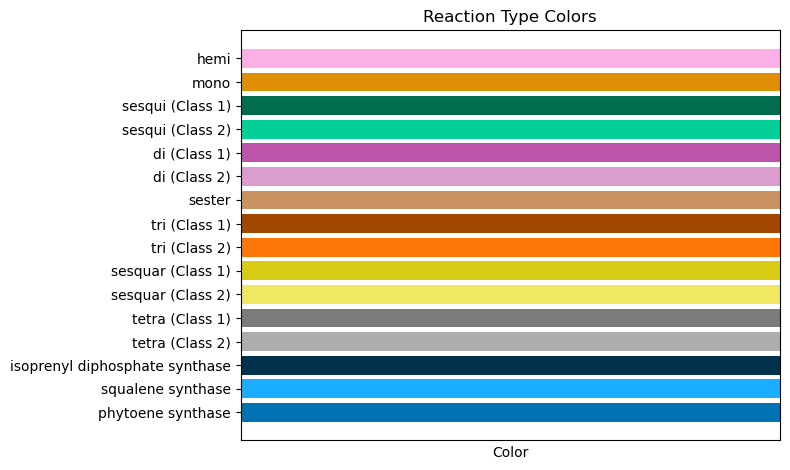

In [174]:
from collections import defaultdict
import colorsys
from matplotlib import cm, colors as mcolors
import seaborn as sns
sns.color_palette("colorblind", n_colors=10)

reaction_types = sorted(martsDB["reaction_type"].unique())
prefix_to_reaction_types: dict[str, list[str]] = defaultdict(list)
for reaction_type in reaction_types:
    prefix = reaction_type.split()[0] if reaction_type else "unknown"
    if prefix == "squalene" or prefix == "phytoene" or prefix == "isoprenyl":
        prefix = "sqs-psy-ids"
    prefix_to_reaction_types[prefix].append(reaction_type)

prefixes = sorted(prefix_to_reaction_types.keys(), key=lambda rt: [
    "sqs-psy-ids",
    "mono",
    "sesqui",
    "tri",
    "di",
    "sester",
    "hemi",
    "tetra",
    "sesquar",
    ].index(rt)
                                )
base_cmap = sns.color_palette("colorblind", n_colors=10)

reaction_type_2_color: dict[str, str] = {}
for idx, prefix in enumerate(prefixes):
    base_rgb = base_cmap[idx][:3]
    h, l, s = colorsys.rgb_to_hls(*base_rgb)
    group = sorted(prefix_to_reaction_types[prefix])
    n_group = len(group)
    for jdx, reaction_type in enumerate(group):
        if n_group == 1:
            l_adj = l
        else:
            l_adj = l + 0.2 * (jdx - (n_group - 1) / 2)
            # s_adj = s + 0.1 * (jdx - (n_group - 1) / 2)
            h_adj = h + 0.03 * (jdx - (n_group - 1) / 2)
        rgb = colorsys.hls_to_rgb(h, l_adj, s)
        reaction_type_2_color[reaction_type] = mcolors.to_hex(rgb)
ordered_reaction_types = sorted(reaction_type_2_color.keys(), key=lambda rt: [
    "hemi",
    "mono",
    "sesqui (Class 1)",
    "sesqui (Class 2)",
    "di (Class 1)",
    "di (Class 2)",
    "sester",
    "tri (Class 1)",
    "tri (Class 2)",
    "sesquar (Class 1)",
    "sesquar (Class 2)",
    "tetra (Class 1)",
    "tetra (Class 2)",
    "isoprenyl diphosphate synthase",
    "squalene synthase",
    "phytoene synthase",
    ].index(rt)
                                )

fig, ax = plt.subplots(figsize=(8, max(2, 0.3 * len(ordered_reaction_types))))
ax.barh(
    ordered_reaction_types,
    [1] * len(ordered_reaction_types),
    color=[reaction_type_2_color[rt] for rt in ordered_reaction_types],
)
ax.set_xlabel("Color")
ax.set_title("Reaction Type Colors")
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()

('alpha1A',)
('alpha1B',)
('alpha1B', 'zeta')
('alpha2A',)
('alpha2B',)
('alpha2B', 'alpha3C')
('alpha2C',)
('alpha2C', 'delta2', 'gamma')
('alpha2D',)
('alpha2D', 'beta')
('alpha2D', 'beta', 'gamma')
('alpha2D', 'delta2', 'gamma')
('alpha2E',)
('alpha2F',)
('alpha2F', 'alpha2F')
('alpha2G',)
('alpha3A',)
('alpha3B',)
('alpha3C',)
('alpha3C', 'delta2', 'gamma')
('delta1', 'epsilon')
('delta2',)
('delta2', 'gamma')


/tmp/ipykernel_3531679/694531775.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(1,2))


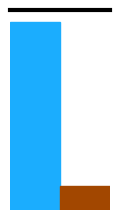

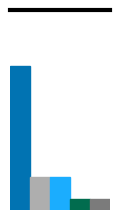

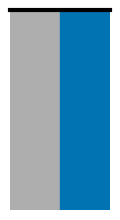

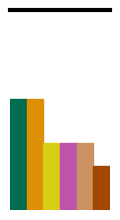

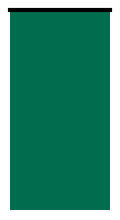

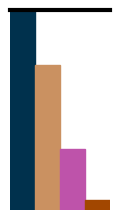

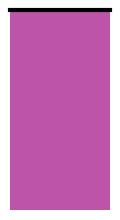

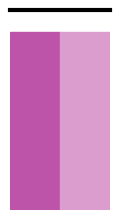

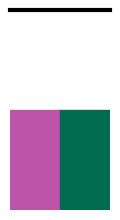

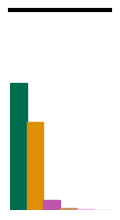

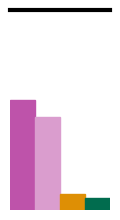

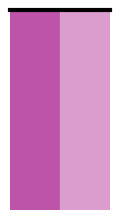

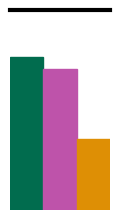

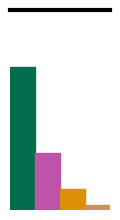

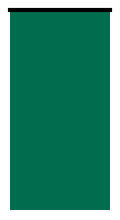

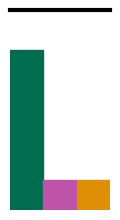

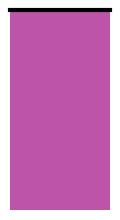

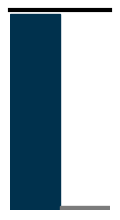

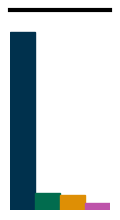

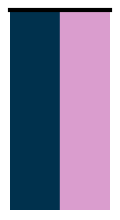

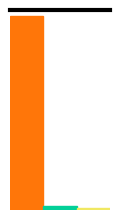

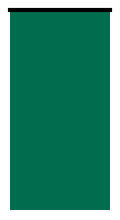

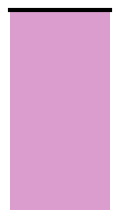

In [175]:
import matplotlib.pyplot as plt
import numpy as np


def plot_bar_square(values, colors="C0"):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        raise ValueError("values must be non-empty")
    widths = np.full(values.size, 1.0 / values.size)
    if values.size > 3:
        widths = widths
    elif values.size == 3:
        widths = widths * 0.75
    elif values.size == 2:
        widths = widths * 0.5
    elif values.size == 1:
        widths = widths * 0.25
    lefts = np.cumsum(np.concatenate(([0.0], widths[:-1])))

    fig, ax = plt.subplots(figsize=(1,2))
    ax.bar(lefts, values, width=widths, align="edge", color=colors, edgecolor=colors)

    ax.set_ylim(0, 1)
    # ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    # plt.axis('off')
    for axis in ['top']:
        ax.spines[axis].set_linewidth(3)
    for axis in ['bottom','left','right']:
        ax.spines[axis].set_linewidth(0)

    ax.margins(0)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

    for spine in ax.spines.values():
        spine.set_visible(True)

    return fig, ax

dom_conf_rxn_type_items = sorted(domain_config_2_reaction_type.items(), key=lambda x:x[0])
for dom_seq, rxn_type_infos in dom_conf_rxn_type_items:
    rxn_type_infos_sorted = sorted(rxn_type_infos, key=lambda x: x[1], reverse=True)
    print(dom_seq)
    plot_bar_square([rxn_type_info[2] for rxn_type_info in rxn_type_infos_sorted], colors=[reaction_type_2_color[rxn_type_info[0]] for rxn_type_info in rxn_type_infos_sorted])

### Kingdoms

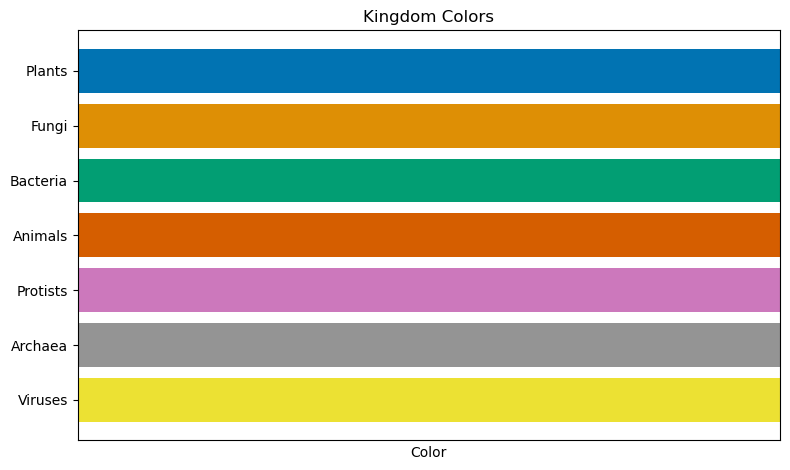

In [137]:
colors = sns.color_palette("colorblind", n_colors=len(set(martsDB.Kingdom.unique()))+2)
colors = colors[:5] + colors[7:]

kingdom_2_color = dict(zip(['Plants', 'Fungi', 'Bacteria', 'Animals', 'Protists', 'Archaea','Viruses'], colors))
fig, ax = plt.subplots(figsize=(8, max(2, 0.3 * len(ordered_reaction_types))))
ax.barh(
    kingdom_2_color.keys(),
    [1] * len(kingdom_2_color),
    color=[kingdom_2_color[k] for k in kingdom_2_color.keys()],
)
ax.set_xlabel("Color")
ax.set_title("Kingdom Colors")
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3531679/2623464509.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(2, 2))


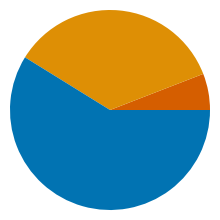

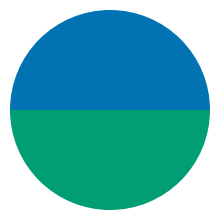

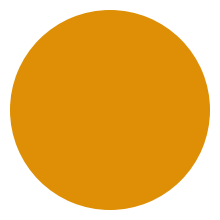

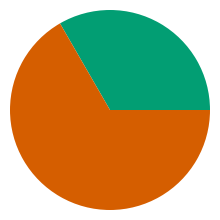

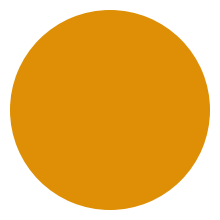

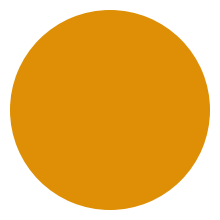

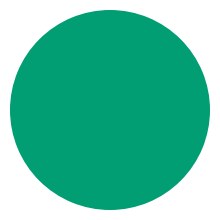

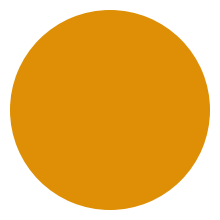

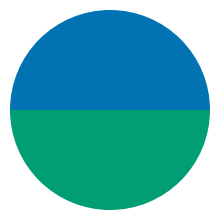

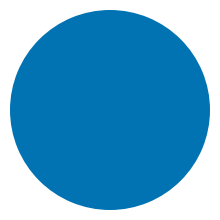

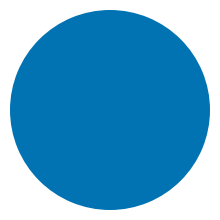

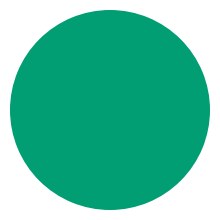

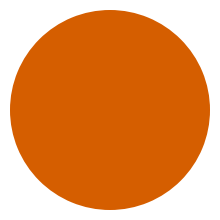

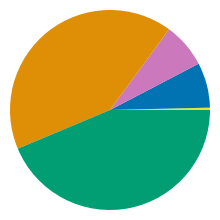

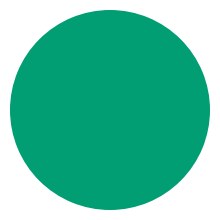

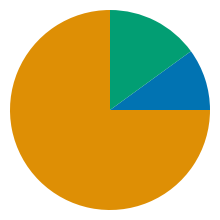

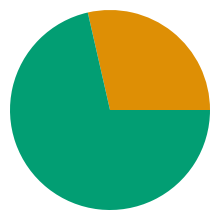

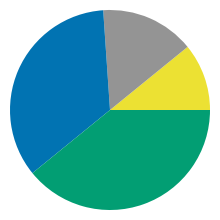

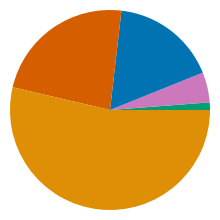

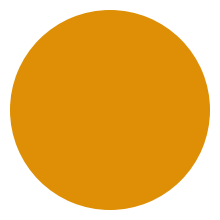

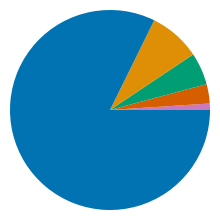

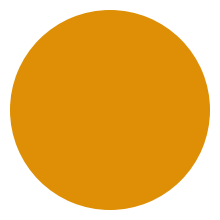

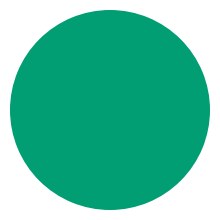

In [138]:
dom_config_to_kingdom_items = sorted(domain_config_2_kingdoms.items(), key=lambda x:x[0])

for dom_seq, kingdom_infos in dom_config_to_kingdom_items:
    fig, ax = plt.subplots(figsize=(2, 2))
    kingdom_infos_sorted = sorted(kingdom_infos, key=lambda x: x[1])
    ax.pie([kingdom_info[1] for kingdom_info in kingdom_infos_sorted], colors=[kingdom_2_color[kingdom_info[0]] for kingdom_info in kingdom_infos_sorted])
    ax.axis('equal')
    ax.margins(0, 0)
    fig.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

In [136]:
kingdom_2_color

{'Plants': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 'Fungi': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 'Bacteria': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 'Animals': (0.8352941176470589, 0.3686274509803922, 0.0),
 'Protists': (0.8, 0.47058823529411764, 0.7372549019607844),
 'Archaea': (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 'Viruses': (0.984313725490196, 0.6862745098039216, 0.8941176470588236)}